# Análise Estatística — Surrogate (DVL) vs. MOEA original

Para **cada instância** `(problema, M, nº de avaliações)` comparamos **todas as 12
configurações** ao mesmo tempo — as 3 MOEAs (MOEA/D, NSGA-II, NSGA-III) em suas 4
variações (**Puro** e **DVL 25% / 50% / 75%** do orçamento de avaliações).

**Metodologia** (igual ao código enviado pelo professor e aos apêndices da dissertação
do Artur):
1. **Kruskal-Wallis** (teste global) verifica se há diferença entre as 12 configurações.
2. **Conover** (pós-hoc pareado) dá o *p-value* de cada par de configurações.
3. **Melhor em negrito**: marca a configuração com **melhor média** e todas as que **não
   diferem estatisticamente** dela (Conover $p \ge 0{,}05$).
4. **Vitórias/Empates/Derrotas**: compila, sobre todos os testes, quantas vezes cada
   configuração foi significativamente melhor / equivalente / pior que as demais.
5. **Heatmaps** de Conover por instância (estilo dos anexos do Artur), no fim do notebook.

> Analisamos **duas métricas separadamente**: **Hipervolume** (maior é melhor — discussão
> principal) e **Tempo de CPU** (menor é melhor — discussão complementar). A pergunta central
> é: *qual a diferença de desempenho dos surrogates (DVL) frente às MOEAs originais, conforme
> varia o número de avaliações?* Espera-se que o DVL seja **mais rápido** porém com **pior
> qualidade** — esta análise quantifica isso.

In [12]:
import os
import warnings
import pandas as pd
import numpy as np
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

%matplotlib inline

CSV_PATH = "out/all_results.csv"
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"{CSV_PATH} não encontrado. Rode os experimentos primeiro.")

df = pd.read_csv(CSV_PATH)
if "status" in df.columns:
    df = df[df["status"] == "success"].copy()
print(f"{len(df)} registros carregados de {CSV_PATH}.")

11520 registros carregados de out/all_results.csv.


In [13]:
# --- Rótulos e ordem canônica das configurações -----------------------------
ALPHA = 0.05  # nível de significância do Conover

ALGO_DISPLAY = {"MOEAD": "MOEA/D", "NSGAII": "NSGA-II", "NSGAIII": "NSGA-III"}
VAR_DISPLAY = {"pure_moea": "Puro", "dvl_25": "DVL 25%",
               "dvl_50": "DVL 50%", "dvl_75": "DVL 75%"}
ALGO_ORDER = ["MOEA/D", "NSGA-II", "NSGA-III"]
VAR_ORDER = ["Puro", "DVL 25%", "DVL 50%", "DVL 75%"]
# Configuração = algoritmo + variação (12 ao todo).
CONFIG_ORDER = [f"{a} {v}" for a in ALGO_ORDER for v in VAR_ORDER]
DVL_VARS = VAR_ORDER[1:]  # variações que usam o surrogate

df["algo_d"] = df["algorithm"].map(ALGO_DISPLAY)
df["var_d"] = df["variation"].map(VAR_DISPLAY)
df["config"] = df["algo_d"] + " " + df["var_d"]

INSTANCE_KEYS = ["problem", "m", "max_evaluations"]
n_inst = df.groupby(INSTANCE_KEYS).ngroups
print(f"{n_inst} instâncias (problema × M × avaliações), "
      f"{df.groupby(INSTANCE_KEYS + ['config']).ngroups // n_inst} configs cada.")
print("Avaliações:", sorted(df.max_evaluations.unique()))
print("Configurações:", CONFIG_ORDER)

48 instâncias (problema × M × avaliações), 12 configs cada.
Avaliações: [250, 500, 1000, 1500, 10000, 100000]
Configurações: ['MOEA/D Puro', 'MOEA/D DVL 25%', 'MOEA/D DVL 50%', 'MOEA/D DVL 75%', 'NSGA-II Puro', 'NSGA-II DVL 25%', 'NSGA-II DVL 50%', 'NSGA-II DVL 75%', 'NSGA-III Puro', 'NSGA-III DVL 25%', 'NSGA-III DVL 50%', 'NSGA-III DVL 75%']


In [14]:
# --- Núcleo: análise estatística de uma instância ---------------------------
def analyze_instance(inst, metric, higher_is_better):
    '''Kruskal-Wallis (global) + Conover (pós-hoc) sobre as configs de uma
    instância. Identifica o melhor (média) e as configs equivalentes (Conover
    p >= ALPHA), que entram em negrito.'''
    configs = [c for c in CONFIG_ORDER if c in set(inst["config"])]
    data = [inst.loc[inst["config"] == c].sort_values("seed")[metric].values
            for c in configs]
    means = {c: float(np.mean(d)) for c, d in zip(configs, data)}
    stds = {c: float(np.std(d, ddof=1)) for c, d in zip(configs, data)}

    allv = np.concatenate(data)
    if np.allclose(allv, allv[0]):  # tudo idêntico -> sem diferença possível
        kw_p, pc = 1.0, pd.DataFrame(1.0, index=configs, columns=configs)
    else:
        kw_p = float(stats.kruskal(*data).pvalue)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            pc = sp.posthoc_conover(data)
        pc.index, pc.columns = configs, configs
        pc = pc.fillna(1.0)

    best = (max if higher_is_better else min)(means, key=means.get)
    bold = {c for c in configs if c == best or pc.loc[best, c] >= ALPHA}
    return dict(configs=configs, means=means, stds=stds, conover=pc,
                kw_p=kw_p, best=best, bold=bold)


def _better(x, y, higher_is_better):
    return (x > y) if higher_is_better else (x < y)


def run_metric(metric, higher_is_better):
    '''Roda a análise em todas as instâncias. Retorna:
    - rows: dict {(problema, M, avals): resultado de analyze_instance}
    - wtl:  V/E/D pareado de cada config contra todas as outras (todos os testes).'''
    rows = {}
    wtl = {c: [0, 0, 0] for c in CONFIG_ORDER}  # [Vitórias, Empates, Derrotas]
    for keys, inst in df.groupby(INSTANCE_KEYS):
        res = analyze_instance(inst, metric, higher_is_better)
        rows[keys] = res
        cfgs, means, pc = res["configs"], res["means"], res["conover"]
        for a in cfgs:
            for b in cfgs:
                if a == b:
                    continue
                if pc.loc[a, b] >= ALPHA:
                    wtl[a][1] += 1                                   # Empate
                elif _better(means[a], means[b], higher_is_better):
                    wtl[a][0] += 1                                   # Vitória
                else:
                    wtl[a][2] += 1                                   # Derrota
    return rows, wtl

In [15]:
# --- Executa para as duas métricas ------------------------------------------
hv_rows, hv_wtl = run_metric("hypervolume", higher_is_better=True)
tm_rows, tm_wtl = run_metric("cpu_time_seconds", higher_is_better=False)
print(f"Hipervolume: {len(hv_rows)} instâncias analisadas.")
print(f"Tempo de CPU: {len(tm_rows)} instâncias analisadas.")

# Quantas instâncias o KW achou diferença significativa global (sanidade):
hv_sig = sum(r["kw_p"] < ALPHA for r in hv_rows.values())
tm_sig = sum(r["kw_p"] < ALPHA for r in tm_rows.values())
print(f"KW significativo (p<{ALPHA}): HV {hv_sig}/{len(hv_rows)}, "
      f"Tempo {tm_sig}/{len(tm_rows)}.")

Hipervolume: 48 instâncias analisadas.
Tempo de CPU: 48 instâncias analisadas.
KW significativo (p<0.05): HV 48/48, Tempo 48/48.


## 1. Melhores configurações em negrito (média ± desvio)

Formato compacto das **Tabelas 19/20 do Artur**, uma por `(problema, M)`: colunas =
algoritmos (MOEA/D, NSGA-II, NSGA-III); linhas = nº de avaliações × variação. Em
**negrito**, a melhor média da instância e todas as estatisticamente equivalentes a ela
(Conover $p \ge 0{,}05$). Saída em Markdown (para conferência) e em LaTeX (requer os
pacotes `booktabs` e `multirow`).

In [16]:
def _fmt(mean, std, bold, decimals, latex):
    if latex:
        body = f"{mean:.{decimals}f} \\pm {std:.{decimals}f}"
        return f"$\\mathbf{{{body}}}$" if bold else f"${body}$"
    body = f"{mean:.{decimals}f} ± {std:.{decimals}f}"
    return f"**{body}**" if bold else body


def build_bold_tables(rows, metric_label, decimals, latex_label_prefix):
    '''Tabela compacta estilo Tabelas 19/20 do Artur, por (problema, M):
    colunas = algoritmos; linhas = (nº de avaliações × variação).
    Negrito = melhor média e equivalentes (Conover p >= ALPHA).'''
    problems = sorted({k[0] for k in rows})
    ms = sorted({k[1] for k in rows})
    for problem in problems:
        for m in ms:
            evals_list = sorted({k[2] for k in rows if k[0] == problem and k[1] == m})
            if not evals_list:
                continue
            # --- Markdown ---
            md_lines = ["| Aval. | Variação | " + " | ".join(ALGO_ORDER) + " |",
                        "|---|---|" + "---|" * len(ALGO_ORDER)]
            for e in evals_list:
                res = rows[(problem, m, e)]
                for vi, v in enumerate(VAR_ORDER):
                    cells_md = [str(e) if vi == 0 else "", v]
                    for a in ALGO_ORDER:
                        cfg = f"{a} {v}"
                        if cfg not in res["means"]:
                            cells_md.append("--"); continue
                        cells_md.append(_fmt(res["means"][cfg], res["stds"][cfg],
                                             cfg in res["bold"], decimals, latex=False))
                    md_lines.append("| " + " | ".join(cells_md) + " |")
            display(Markdown(f"#### {metric_label} — {problem}, M={m}\n"
                             + "\n".join(md_lines)))
            # --- LaTeX (multirow p/ a coluna de avaliações) ---
            col_fmt = "ll" + "c" * len(ALGO_ORDER)
            tex = [r"\begin{table}[ht]", r"  \centering",
                   f"  \\caption{{{metric_label} para {problem} (M={m}). "
                   f"Negrito = melhor média e equivalentes (Conover $p\\ge0{{,}}05$).}}",
                   f"  \\label{{tab:{latex_label_prefix}_{problem.lower()}_m{m}}}",
                   f"  \\begin{{tabular}}{{{col_fmt}}}", r"    \toprule",
                   "    Aval. & Variação & " +
                   " & ".join(a.replace("%", r"\%") for a in ALGO_ORDER) + r" \\",
                   r"    \midrule"]
            for e in evals_list:
                res = rows[(problem, m, e)]
                for vi, v in enumerate(VAR_ORDER):
                    if vi == 0:
                        parts = [f"\\multirow{{{len(VAR_ORDER)}}}{{*}}{{{e}}}",
                                 v.replace("%", r"\%")]
                    else:
                        parts = ["", v.replace("%", r"\%")]
                    for a in ALGO_ORDER:
                        cfg = f"{a} {v}"
                        if cfg not in res["means"]:
                            parts.append("--"); continue
                        parts.append(_fmt(res["means"][cfg], res["stds"][cfg],
                                          cfg in res["bold"], decimals, latex=True))
                    tex.append("    " + " & ".join(parts) + r" \\")
                if e != evals_list[-1]:
                    tex.append(r"    \midrule")
            tex += [r"    \bottomrule", r"  \end{tabular}", r"\end{table}"]
            print("\n".join(tex)); print()


build_bold_tables(hv_rows, "Hipervolume", decimals=4, latex_label_prefix="hv")

#### Hipervolume — DTLZ1, M=3
| Aval. | Variação | MOEA/D | NSGA-II | NSGA-III |
|---|---|---|---|---|
| 250 | Puro | 0.0000 ± 0.0000 | 0.0000 ± 0.0000 | **0.5256 ± 0.1243** |
|  | DVL 25% | 0.0000 ± 0.0000 | 0.0000 ± 0.0000 | 0.0000 ± 0.0000 |
|  | DVL 50% | 0.0411 ± 0.0688 | 0.0521 ± 0.0775 | 0.0746 ± 0.0877 |
|  | DVL 75% | 0.2976 ± 0.1039 | 0.2976 ± 0.1039 | 0.3415 ± 0.1086 |
| 500 | Puro | 0.0000 ± 0.0000 | 0.0000 ± 0.0000 | 0.5367 ± 0.1145 |
|  | DVL 25% | 0.0433 ± 0.0786 | 0.1068 ± 0.0826 | 0.1035 ± 0.0842 |
|  | DVL 50% | 0.4554 ± 0.1581 | 0.5647 ± 0.0709 | 0.5686 ± 0.0697 |
|  | DVL 75% | 0.5619 ± 0.0047 | 0.5677 ± 0.0199 | **0.6115 ± 0.0182** |
| 1000 | Puro | 0.0000 ± 0.0000 | 0.0000 ± 0.0000 | 0.5748 ± 0.1005 |
|  | DVL 25% | 0.3033 ± 0.2817 | 0.6180 ± 0.0669 | **0.6468 ± 0.0852** |
|  | DVL 50% | 0.3998 ± 0.2576 | **0.6521 ± 0.0292** | **0.6568 ± 0.0311** |
|  | DVL 75% | 0.5758 ± 0.0207 | 0.6343 ± 0.0237 | **0.6372 ± 0.0212** |
| 1500 | Puro | 0.0000 ± 0.0000 | 0.0000 ± 0.0000 | 0.7550 ± 0.1816 |
|  | DVL 25% | 0.4653 ± 0.2830 | **0.7027 ± 0.0233** | **0.7692 ± 0.1037** |
|  | DVL 50% | 0.4397 ± 0.2648 | 0.6843 ± 0.0229 | 0.7078 ± 0.0729 |
|  | DVL 75% | 0.5370 ± 0.1266 | 0.6465 ± 0.0305 | 0.6470 ± 0.0260 |
| 10000 | Puro | 0.0017 ± 0.0075 | 0.0000 ± 0.0000 | **0.9931 ± 0.0099** |
|  | DVL 25% | 0.0482 ± 0.2150 | 0.6583 ± 0.2592 | 0.8969 ± 0.0919 |
|  | DVL 50% | 0.1296 ± 0.3187 | 0.1362 ± 0.1662 | 0.7566 ± 0.2487 |
|  | DVL 75% | 0.0856 ± 0.2634 | 0.0000 ± 0.0000 | 0.3324 ± 0.3263 |
| 100000 | Puro | 0.9670 ± 0.0003 | 0.9691 ± 0.0011 | **0.9974 ± 0.0088** |
|  | DVL 25% | 0.9667 ± 0.0005 | 0.9683 ± 0.0016 | 0.9643 ± 0.0426 |
|  | DVL 50% | 0.9434 ± 0.0704 | 0.9672 ± 0.0023 | 0.9698 ± 0.0391 |
|  | DVL 75% | 0.7141 ± 0.2960 | 0.9612 ± 0.0056 | 0.9580 ± 0.0532 |

\begin{table}[ht]
  \centering
  \caption{Hipervolume para DTLZ1 (M=3). Negrito = melhor média e equivalentes (Conover $p\ge0{,}05$).}
  \label{tab:hv_dtlz1_m3}
  \begin{tabular}{llccc}
    \toprule
    Aval. & Variação & MOEA/D & NSGA-II & NSGA-III \\
    \midrule
    \multirow{4}{*}{250} & Puro & $0.0000 \pm 0.0000$ & $0.0000 \pm 0.0000$ & $\mathbf{0.5256 \pm 0.1243}$ \\
     & DVL 25\% & $0.0000 \pm 0.0000$ & $0.0000 \pm 0.0000$ & $0.0000 \pm 0.0000$ \\
     & DVL 50\% & $0.0411 \pm 0.0688$ & $0.0521 \pm 0.0775$ & $0.0746 \pm 0.0877$ \\
     & DVL 75\% & $0.2976 \pm 0.1039$ & $0.2976 \pm 0.1039$ & $0.3415 \pm 0.1086$ \\
    \midrule
    \multirow{4}{*}{500} & Puro & $0.0000 \pm 0.0000$ & $0.0000 \pm 0.0000$ & $0.5367 \pm 0.1145$ \\
     & DVL 25\% & $0.0433 \pm 0.0786$ & $0.1068 \pm 0.0826$ & $0.1035 \pm 0.0842$ \\
     & DVL 50\% & $0.4554 \pm 0.1581$ & $0.5647 \pm 0.0709$ & $0.5686 \pm 0.0697$ \\
     & DVL 75\% & $0.5619 \pm 0.0047$ & $0.5677 \pm 0.0199$ & $\mathbf{0.6115 \pm 0.0

#### Hipervolume — DTLZ1, M=10
| Aval. | Variação | MOEA/D | NSGA-II | NSGA-III |
|---|---|---|---|---|
| 250 | Puro | 0.0002 ± 0.0008 | 0.0073 ± 0.0324 | **0.9326 ± 0.0282** |
|  | DVL 25% | 0.3125 ± 0.2068 | 0.3083 ± 0.2124 | 0.6032 ± 0.2016 |
|  | DVL 50% | 0.7835 ± 0.1247 | 0.7837 ± 0.1252 | 0.8341 ± 0.1140 |
|  | DVL 75% | 0.8528 ± 0.0488 | 0.8521 ± 0.0489 | 0.8761 ± 0.0400 |
| 500 | Puro | 0.0986 ± 0.1732 | 0.0212 ± 0.0567 | **0.9947 ± 0.0032** |
|  | DVL 25% | 0.8807 ± 0.0743 | 0.8634 ± 0.0391 | 0.8721 ± 0.0387 |
|  | DVL 50% | 0.9036 ± 0.0660 | 0.8920 ± 0.0593 | 0.9099 ± 0.0268 |
|  | DVL 75% | 0.8415 ± 0.1481 | 0.8126 ± 0.1783 | 0.8369 ± 0.1742 |
| 1000 | Puro | 0.4160 ± 0.3457 | 0.0490 ± 0.0807 | **0.9996 ± 0.0004** |
|  | DVL 25% | 0.8547 ± 0.2747 | 0.9171 ± 0.0244 | 0.9436 ± 0.0328 |
|  | DVL 50% | 0.9255 ± 0.0288 | 0.8999 ± 0.0273 | 0.9116 ± 0.0321 |
|  | DVL 75% | 0.9058 ± 0.0280 | 0.8582 ± 0.0666 | 0.8677 ± 0.0719 |
| 1500 | Puro | 0.5750 ± 0.4043 | 0.1287 ± 0.1554 | **0.9999 ± 0.0001** |
|  | DVL 25% | 0.9376 ± 0.1353 | 0.8935 ± 0.1270 | 0.9448 ± 0.0575 |
|  | DVL 50% | 0.9500 ± 0.0143 | 0.8968 ± 0.0309 | 0.9153 ± 0.0462 |
|  | DVL 75% | 0.9129 ± 0.0543 | 0.8387 ± 0.1868 | 0.8471 ± 0.1802 |
| 10000 | Puro | 0.9731 ± 0.1135 | 0.0010 ± 0.0046 | **1.0000 ± 0.0000** |
|  | DVL 25% | 0.9967 ± 0.0045 | 0.9915 ± 0.0073 | 0.9965 ± 0.0055 |
|  | DVL 50% | 0.9930 ± 0.0087 | 0.9699 ± 0.0139 | 0.9878 ± 0.0081 |
|  | DVL 75% | 0.9863 ± 0.0215 | 0.8614 ± 0.0657 | 0.9198 ± 0.0400 |
| 100000 | Puro | 0.9999 ± 0.0001 | 0.0357 ± 0.1573 | **1.0000 ± 0.0000** |
|  | DVL 25% | 0.9999 ± 0.0001 | 0.5711 ± 0.4099 | **1.0000 ± 0.0001** |
|  | DVL 50% | 0.9999 ± 0.0001 | 0.6914 ± 0.3716 | **1.0000 ± 0.0000** |
|  | DVL 75% | 0.9996 ± 0.0007 | 0.9002 ± 0.1219 | 0.9983 ± 0.0077 |

\begin{table}[ht]
  \centering
  \caption{Hipervolume para DTLZ1 (M=10). Negrito = melhor média e equivalentes (Conover $p\ge0{,}05$).}
  \label{tab:hv_dtlz1_m10}
  \begin{tabular}{llccc}
    \toprule
    Aval. & Variação & MOEA/D & NSGA-II & NSGA-III \\
    \midrule
    \multirow{4}{*}{250} & Puro & $0.0002 \pm 0.0008$ & $0.0073 \pm 0.0324$ & $\mathbf{0.9326 \pm 0.0282}$ \\
     & DVL 25\% & $0.3125 \pm 0.2068$ & $0.3083 \pm 0.2124$ & $0.6032 \pm 0.2016$ \\
     & DVL 50\% & $0.7835 \pm 0.1247$ & $0.7837 \pm 0.1252$ & $0.8341 \pm 0.1140$ \\
     & DVL 75\% & $0.8528 \pm 0.0488$ & $0.8521 \pm 0.0489$ & $0.8761 \pm 0.0400$ \\
    \midrule
    \multirow{4}{*}{500} & Puro & $0.0986 \pm 0.1732$ & $0.0212 \pm 0.0567$ & $\mathbf{0.9947 \pm 0.0032}$ \\
     & DVL 25\% & $0.8807 \pm 0.0743$ & $0.8634 \pm 0.0391$ & $0.8721 \pm 0.0387$ \\
     & DVL 50\% & $0.9036 \pm 0.0660$ & $0.8920 \pm 0.0593$ & $0.9099 \pm 0.0268$ \\
     & DVL 75\% & $0.8415 \pm 0.1481$ & $0.8126 \pm 0.1783$ & $0.8369 \pm 

#### Hipervolume — DTLZ2, M=3
| Aval. | Variação | MOEA/D | NSGA-II | NSGA-III |
|---|---|---|---|---|
| 250 | Puro | 0.7292 ± 0.0469 | 0.6958 ± 0.0215 | **0.8793 ± 0.0353** |
|  | DVL 25% | 0.6848 ± 0.0517 | 0.5838 ± 0.1108 | 0.8265 ± 0.0617 |
|  | DVL 50% | 0.6777 ± 0.0671 | 0.7079 ± 0.0458 | **0.8874 ± 0.0427** |
|  | DVL 75% | 0.6964 ± 0.0479 | 0.7730 ± 0.0354 | 0.8429 ± 0.0396 |
| 500 | Puro | 0.8436 ± 0.0243 | 0.8084 ± 0.0156 | **0.9535 ± 0.0215** |
|  | DVL 25% | 0.8382 ± 0.0317 | 0.8524 ± 0.0201 | **0.9691 ± 0.0114** |
|  | DVL 50% | 0.8267 ± 0.0407 | 0.8597 ± 0.0216 | 0.9472 ± 0.0225 |
|  | DVL 75% | 0.7854 ± 0.0446 | 0.8465 ± 0.0230 | 0.9208 ± 0.0180 |
| 1000 | Puro | 0.8945 ± 0.0119 | 0.8855 ± 0.0080 | **0.9804 ± 0.0109** |
|  | DVL 25% | 0.8931 ± 0.0219 | 0.9045 ± 0.0093 | **0.9794 ± 0.0120** |
|  | DVL 50% | 0.8574 ± 0.0388 | 0.8899 ± 0.0153 | 0.9615 ± 0.0110 |
|  | DVL 75% | 0.8447 ± 0.0286 | 0.8676 ± 0.0163 | 0.9370 ± 0.0197 |
| 1500 | Puro | 0.9113 ± 0.0043 | 0.8997 ± 0.0047 | **0.9906 ± 0.0059** |
|  | DVL 25% | 0.9057 ± 0.0126 | 0.9101 ± 0.0057 | **0.9813 ± 0.0101** |
|  | DVL 50% | 0.8940 ± 0.0191 | 0.8979 ± 0.0120 | 0.9631 ± 0.0133 |
|  | DVL 75% | 0.8612 ± 0.0317 | 0.8831 ± 0.0199 | 0.9412 ± 0.0066 |
| 10000 | Puro | 0.9218 ± 0.0004 | 0.9176 ± 0.0030 | **0.9985 ± 0.0013** |
|  | DVL 25% | 0.9216 ± 0.0004 | 0.9169 ± 0.0035 | 0.9835 ± 0.0053 |
|  | DVL 50% | 0.9213 ± 0.0007 | 0.9161 ± 0.0038 | 0.9823 ± 0.0073 |
|  | DVL 75% | 0.9204 ± 0.0009 | 0.9134 ± 0.0040 | 0.9812 ± 0.0069 |
| 100000 | Puro | 0.9210 ± 0.0000 | 0.9189 ± 0.0021 | **0.9980 ± 0.0014** |
|  | DVL 25% | 0.9211 ± 0.0000 | 0.9191 ± 0.0020 | 0.9900 ± 0.0050 |
|  | DVL 50% | 0.9211 ± 0.0001 | 0.9193 ± 0.0018 | 0.9906 ± 0.0049 |
|  | DVL 75% | 0.9213 ± 0.0001 | 0.9183 ± 0.0023 | 0.9861 ± 0.0057 |

...

\begin{table}[ht]
  \centering
  \caption{Hipervolume para DTLZ3 (M=10). Negrito = melhor média e equivalentes (Conover $p\ge0{,}05$).}
  \label{tab:hv_dtlz3_m10}
  \begin{tabular}{llccc}
    \toprule
    Aval. & Variação & MOEA/D & NSGA-II & NSGA-III \\
    \midrule
    \multirow{4}{*}{250} & Puro & $0.1906 \pm 0.2283$ & $0.1789 \pm 0.1974$ & $\mathbf{0.9943 \pm 0.0021}$ \\
     & DVL 25\% & $0.6555 \pm 0.1175$ & $0.6098 \pm 0.1430$ & $0.7832 \pm 0.1283$ \\
     & DVL 50\% & $0.9167 \pm 0.0227$ & $0.9139 \pm 0.0217$ & $0.9344 \pm 0.0174$ \\
     & DVL 75\% & $0.9426 \pm 0.0107$ & $0.9401 \pm 0.0101$ & $0.9488 \pm 0.0088$ \\
    \midrule
    \multirow{4}{*}{500} & Puro & $0.6240 \pm 0.2896$ & $0.3701 \pm 0.1504$ & $\mathbf{0.9987 \pm 0.0015}$ \\
     & DVL 25\% & $0.8909 \pm 0.1559$ & $0.9404 \pm 0.0158$ & $0.9422 \pm 0.0149$ \\
     & DVL 50\% & $0.9520 \pm 0.0057$ & $0.9500 \pm 0.0052$ & $0.9628 \pm 0.0036$ \\
     & DVL 75\% & $0.9530 \pm 0.0029$ & $0.9521 \pm 0.0014$ & $0.9620 \pm 

#### Hipervolume — DTLZ4, M=3
| Aval. | Variação | MOEA/D | NSGA-II | NSGA-III |
|---|---|---|---|---|
| 250 | Puro | 0.5305 ± 0.0974 | 0.4435 ± 0.0553 | 0.6191 ± 0.1352 |
|  | DVL 25% | 0.6093 ± 0.1258 | 0.4244 ± 0.2258 | 0.6160 ± 0.1604 |
|  | DVL 50% | 0.6693 ± 0.1225 | 0.6102 ± 0.0789 | **0.6911 ± 0.0739** |
|  | DVL 75% | 0.6685 ± 0.1019 | **0.7133 ± 0.0615** | **0.7396 ± 0.0568** |
| 500 | Puro | 0.6371 ± 0.1319 | 0.6098 ± 0.0874 | 0.7802 ± 0.0931 |
|  | DVL 25% | **0.8744 ± 0.0299** | 0.7498 ± 0.0457 | 0.8586 ± 0.0292 |
|  | DVL 50% | **0.8775 ± 0.0205** | 0.8163 ± 0.0262 | 0.8504 ± 0.0258 |
|  | DVL 75% | 0.8592 ± 0.0225 | 0.8472 ± 0.0137 | 0.8542 ± 0.0140 |
| 1000 | Puro | 0.6783 ± 0.1525 | 0.7670 ± 0.1200 | 0.8793 ± 0.0839 |
|  | DVL 25% | **0.9140 ± 0.0030** | 0.8926 ± 0.0106 | **0.9197 ± 0.0163** |
|  | DVL 50% | **0.9119 ± 0.0042** | 0.8980 ± 0.0065 | **0.9091 ± 0.0058** |
|  | DVL 75% | 0.9048 ± 0.0051 | 0.8932 ± 0.0058 | 0.9003 ± 0.0051 |
| 1500 | Puro | 0.6904 ± 0.1634 | 0.8072 ± 0.1235 | 0.9121 ± 0.0699 |
|  | DVL 25% | 0.9199 ± 0.0014 | 0.9133 ± 0.0036 | **0.9279 ± 0.0079** |
|  | DVL 50% | 0.9180 ± 0.0013 | 0.9150 ± 0.0023 | 0.9199 ± 0.0021 |
|  | DVL 75% | 0.9129 ± 0.0024 | 0.9094 ± 0.0039 | 0.9136 ± 0.0037 |
| 10000 | Puro | 0.7348 ± 0.1646 | 0.8573 ± 0.1014 | **0.9364 ± 0.0656** |
|  | DVL 25% | 0.9223 ± 0.0005 | 0.9212 ± 0.0008 | 0.9294 ± 0.0049 |
|  | DVL 50% | 0.9226 ± 0.0003 | 0.9203 ± 0.0008 | 0.9279 ± 0.0035 |
|  | DVL 75% | 0.9220 ± 0.0005 | 0.9174 ± 0.0012 | **0.9286 ± 0.0063** |
| 100000 | Puro | 0.7737 ± 0.1707 | 0.8990 ± 0.0939 | **0.9480 ± 0.0484** |
|  | DVL 25% | 0.9211 ± 0.0001 | 0.9221 ± 0.0006 | **0.9294 ± 0.0052** |
|  | DVL 50% | 0.9212 ± 0.0001 | 0.9218 ± 0.0010 | **0.9275 ± 0.0011** |
|  | DVL 75% | 0.9214 ± 0.0002 | 0.9216 ± 0.0007 | **0.9279 ± 0.0011** |

\begin{table}[ht]
  \centering
  \caption{Hipervolume para DTLZ4 (M=3). Negrito = melhor média e equivalentes (Conover $p\ge0{,}05$).}
  \label{tab:hv_dtlz4_m3}
  \begin{tabular}{llccc}
    \toprule
    Aval. & Variação & MOEA/D & NSGA-II & NSGA-III \\
    \midrule
    \multirow{4}{*}{250} & Puro & $0.5305 \pm 0.0974$ & $0.4435 \pm 0.0553$ & $0.6191 \pm 0.1352$ \\
     & DVL 25\% & $0.6093 \pm 0.1258$ & $0.4244 \pm 0.2258$ & $0.6160 \pm 0.1604$ \\
     & DVL 50\% & $0.6693 \pm 0.1225$ & $0.6102 \pm 0.0789$ & $\mathbf{0.6911 \pm 0.0739}$ \\
     & DVL 75\% & $0.6685 \pm 0.1019$ & $\mathbf{0.7133 \pm 0.0615}$ & $\mathbf{0.7396 \pm 0.0568}$ \\
    \midrule
    \multirow{4}{*}{500} & Puro & $0.6371 \pm 0.1319$ & $0.6098 \pm 0.0874$ & $0.7802 \pm 0.0931$ \\
     & DVL 25\% & $\mathbf{0.8744 \pm 0.0299}$ & $0.7498 \pm 0.0457$ & $0.8586 \pm 0.0292$ \\
     & DVL 50\% & $\mathbf{0.8775 \pm 0.0205}$ & $0.8163 \pm 0.0262$ & $0.8504 \pm 0.0258$ \\
     & DVL 75\% & $0.8592 \pm 0.0225$ & $0.8472 \

#### Hipervolume — DTLZ4, M=10
| Aval. | Variação | MOEA/D | NSGA-II | NSGA-III |
|---|---|---|---|---|
| 250 | Puro | 0.6237 ± 0.0716 | 0.7290 ± 0.0706 | 0.8734 ± 0.1043 |
|  | DVL 25% | 0.8034 ± 0.0424 | 0.5332 ± 0.1283 | 0.8788 ± 0.0557 |
|  | DVL 50% | 0.8913 ± 0.0350 | 0.8216 ± 0.0668 | **0.9313 ± 0.0217** |
|  | DVL 75% | **0.9266 ± 0.0248** | 0.9002 ± 0.0355 | **0.9381 ± 0.0215** |
| 500 | Puro | 0.7707 ± 0.0487 | 0.7875 ± 0.0429 | 0.9355 ± 0.0310 |
|  | DVL 25% | 0.8335 ± 0.0363 | 0.9529 ± 0.0142 | **0.9928 ± 0.0030** |
|  | DVL 50% | 0.8520 ± 0.0615 | 0.9670 ± 0.0118 | **0.9914 ± 0.0035** |
|  | DVL 75% | 0.9195 ± 0.0308 | 0.9628 ± 0.0109 | 0.9893 ± 0.0025 |
| 1000 | Puro | 0.8366 ± 0.0477 | 0.8820 ± 0.0308 | 0.9679 ± 0.0364 |
|  | DVL 25% | 0.8841 ± 0.0350 | 0.9775 ± 0.0062 | **0.9956 ± 0.0021** |
|  | DVL 50% | 0.9094 ± 0.0184 | 0.9876 ± 0.0033 | 0.9934 ± 0.0020 |
|  | DVL 75% | 0.9294 ± 0.0237 | 0.9893 ± 0.0016 | 0.9915 ± 0.0012 |
| 1500 | Puro | 0.8504 ± 0.0487 | 0.9340 ± 0.0175 | 0.9729 ± 0.0508 |
|  | DVL 25% | 0.9001 ± 0.0160 | 0.9753 ± 0.0042 | **0.9965 ± 0.0011** |
|  | DVL 50% | 0.9038 ± 0.0204 | 0.9913 ± 0.0017 | **0.9957 ± 0.0009** |
|  | DVL 75% | 0.9205 ± 0.0259 | 0.9899 ± 0.0013 | 0.9936 ± 0.0007 |
| 10000 | Puro | 0.8797 ± 0.0096 | 0.7078 ± 0.0329 | **0.9996 ± 0.0005** |
|  | DVL 25% | 0.8691 ± 0.0148 | 0.7373 ± 0.0444 | 0.9982 ± 0.0002 |
|  | DVL 50% | 0.8775 ± 0.0145 | 0.7934 ± 0.0292 | 0.9981 ± 0.0003 |
|  | DVL 75% | 0.8891 ± 0.0130 | 0.9373 ± 0.0172 | 0.9976 ± 0.0004 |
| 100000 | Puro | 0.8546 ± 0.0246 | 0.5622 ± 0.0187 | **0.9990 ± 0.0009** |
|  | DVL 25% | 0.8420 ± 0.0204 | 0.6421 ± 0.0534 | **0.9986 ± 0.0001** |
|  | DVL 50% | 0.8433 ± 0.0301 | 0.6443 ± 0.0382 | 0.9985 ± 0.0001 |
|  | DVL 75% | 0.8434 ± 0.0274 | 0.6688 ± 0.0441 | 0.9985 ± 0.0002 |

\begin{table}[ht]
  \centering
  \caption{Hipervolume para DTLZ4 (M=10). Negrito = melhor média e equivalentes (Conover $p\ge0{,}05$).}
  \label{tab:hv_dtlz4_m10}
  \begin{tabular}{llccc}
    \toprule
    Aval. & Variação & MOEA/D & NSGA-II & NSGA-III \\
    \midrule
    \multirow{4}{*}{250} & Puro & $0.6237 \pm 0.0716$ & $0.7290 \pm 0.0706$ & $0.8734 \pm 0.1043$ \\
     & DVL 25\% & $0.8034 \pm 0.0424$ & $0.5332 \pm 0.1283$ & $0.8788 \pm 0.0557$ \\
     & DVL 50\% & $0.8913 \pm 0.0350$ & $0.8216 \pm 0.0668$ & $\mathbf{0.9313 \pm 0.0217}$ \\
     & DVL 75\% & $\mathbf{0.9266 \pm 0.0248}$ & $0.9002 \pm 0.0355$ & $\mathbf{0.9381 \pm 0.0215}$ \\
    \midrule
    \multirow{4}{*}{500} & Puro & $0.7707 \pm 0.0487$ & $0.7875 \pm 0.0429$ & $0.9355 \pm 0.0310$ \\
     & DVL 25\% & $0.8335 \pm 0.0363$ & $0.9529 \pm 0.0142$ & $\mathbf{0.9928 \pm 0.0030}$ \\
     & DVL 50\% & $0.8520 \pm 0.0615$ & $0.9670 \pm 0.0118$ & $\mathbf{0.9914 \pm 0.0035}$ \\
     & DVL 75\% & $0.9195 \pm 0.0308$ & $0.9628

In [17]:
# Tempo de CPU (menor é melhor) — discussão complementar.
build_bold_tables(tm_rows, "Tempo de CPU (s)", decimals=3, latex_label_prefix="tempo")

#### Tempo de CPU (s) — DTLZ1, M=3
| Aval. | Variação | MOEA/D | NSGA-II | NSGA-III |
|---|---|---|---|---|
| 250 | Puro | **0.047 ± 0.004** | 0.061 ± 0.002 | 0.173 ± 0.009 |
|  | DVL 25% | 0.263 ± 0.031 | 0.254 ± 0.005 | 0.273 ± 0.021 |
|  | DVL 50% | 0.546 ± 0.041 | 0.524 ± 0.016 | 0.559 ± 0.016 |
|  | DVL 75% | 0.916 ± 0.033 | 0.904 ± 0.026 | 0.907 ± 0.005 |
| 500 | Puro | **0.096 ± 0.008** | 0.162 ± 0.011 | 0.418 ± 0.021 |
|  | DVL 25% | 0.571 ± 0.008 | 0.606 ± 0.008 | 0.658 ± 0.034 |
|  | DVL 50% | 1.311 ± 0.016 | 1.329 ± 0.015 | 1.366 ± 0.036 |
|  | DVL 75% | 2.556 ± 0.016 | 2.560 ± 0.015 | 2.606 ± 0.020 |
| 1000 | Puro | **0.194 ± 0.002** | 0.357 ± 0.004 | 0.842 ± 0.043 |
|  | DVL 25% | 1.410 ± 0.015 | 1.519 ± 0.023 | 1.688 ± 0.067 |
|  | DVL 50% | 4.605 ± 0.029 | 4.656 ± 0.029 | 4.717 ± 0.055 |
|  | DVL 75% | 10.457 ± 0.047 | 10.467 ± 0.046 | 10.510 ± 0.056 |
| 1500 | Puro | **0.296 ± 0.005** | 0.556 ± 0.025 | 1.309 ± 0.058 |
|  | DVL 25% | 2.764 ± 0.036 | 2.963 ± 0.065 | 3.316 ± 0.068 |
|  | DVL 50% | 10.541 ± 0.046 | 10.674 ± 0.097 | 10.923 ± 0.148 |
|  | DVL 75% | 25.892 ± 0.070 | 26.138 ± 0.238 | 26.279 ± 0.294 |
| 10000 | Puro | **3.558 ± 0.711** | **7.688 ± 0.451** | 15.843 ± 1.011 |
|  | DVL 25% | 33.261 ± 44.988 | 16.996 ± 1.295 | 22.770 ± 1.051 |
|  | DVL 50% | 96.513 ± 200.880 | 15.381 ± 0.888 | 19.198 ± 1.130 |
|  | DVL 75% | 139.448 ± 388.014 | 13.792 ± 0.718 | 15.205 ± 1.076 |
| 100000 | Puro | 36.720 ± 1.886 | 78.815 ± 3.257 | 158.917 ± 12.115 |
|  | DVL 25% | 41.081 ± 1.763 | 69.155 ± 5.319 | 131.588 ± 12.890 |
|  | DVL 50% | 33.313 ± 1.719 | 53.823 ± 2.615 | 96.731 ± 4.608 |
|  | DVL 75% | **25.537 ± 1.294** | 35.080 ± 2.964 | 54.591 ± 4.414 |

\begin{table}[ht]
  \centering
  \caption{Tempo de CPU (s) para DTLZ1 (M=3). Negrito = melhor média e equivalentes (Conover $p\ge0{,}05$).}
  \label{tab:tempo_dtlz1_m3}
  \begin{tabular}{llccc}
    \toprule
    Aval. & Variação & MOEA/D & NSGA-II & NSGA-III \\
    \midrule
    \multirow{4}{*}{250} & Puro & $\mathbf{0.047 \pm 0.004}$ & $0.061 \pm 0.002$ & $0.173 \pm 0.009$ \\
     & DVL 25\% & $0.263 \pm 0.031$ & $0.254 \pm 0.005$ & $0.273 \pm 0.021$ \\
     & DVL 50\% & $0.546 \pm 0.041$ & $0.524 \pm 0.016$ & $0.559 \pm 0.016$ \\
     & DVL 75\% & $0.916 \pm 0.033$ & $0.904 \pm 0.026$ & $0.907 \pm 0.005$ \\
    \midrule
    \multirow{4}{*}{500} & Puro & $\mathbf{0.096 \pm 0.008}$ & $0.162 \pm 0.011$ & $0.418 \pm 0.021$ \\
     & DVL 25\% & $0.571 \pm 0.008$ & $0.606 \pm 0.008$ & $0.658 \pm 0.034$ \\
     & DVL 50\% & $1.311 \pm 0.016$ & $1.329 \pm 0.015$ & $1.366 \pm 0.036$ \\
     & DVL 75\% & $2.556 \pm 0.016$ & $2.560 \pm 0.015$ & $2.606 \pm 0.020$ \\
    \midrule
    \multirow{4}{*

#### Tempo de CPU (s) — DTLZ1, M=10
| Aval. | Variação | MOEA/D | NSGA-II | NSGA-III |
|---|---|---|---|---|
| 250 | Puro | 0.206 ± 0.019 | **0.125 ± 0.020** | 0.829 ± 0.035 |
|  | DVL 25% | 0.595 ± 0.078 | 0.449 ± 0.065 | 0.941 ± 0.187 |
|  | DVL 50% | 1.160 ± 0.083 | 1.035 ± 0.059 | 1.498 ± 0.168 |
|  | DVL 75% | 1.860 ± 0.189 | 1.708 ± 0.173 | 2.208 ± 0.203 |
| 500 | Puro | **0.315 ± 0.037** | 0.619 ± 0.093 | 1.833 ± 0.252 |
|  | DVL 25% | 1.133 ± 0.068 | 1.271 ± 0.111 | 1.847 ± 0.506 |
|  | DVL 50% | 3.011 ± 0.179 | 3.026 ± 0.240 | 3.583 ± 0.343 |
|  | DVL 75% | 6.708 ± 0.260 | 6.296 ± 0.190 | 6.700 ± 0.375 |
| 1000 | Puro | **0.494 ± 0.036** | 1.607 ± 0.110 | 4.187 ± 0.285 |
|  | DVL 25% | 3.043 ± 0.140 | 3.800 ± 0.399 | 5.486 ± 0.678 |
|  | DVL 50% | 12.849 ± 0.261 | 13.219 ± 0.447 | 14.889 ± 0.527 |
|  | DVL 75% | 38.160 ± 0.412 | 37.667 ± 0.712 | 39.219 ± 0.803 |
| 1500 | Puro | **0.677 ± 0.088** | 2.549 ± 0.100 | 6.180 ± 0.278 |
|  | DVL 25% | 6.479 ± 0.283 | 7.997 ± 0.561 | 10.451 ± 0.483 |
|  | DVL 50% | 37.777 ± 0.712 | 38.059 ± 0.592 | 40.530 ± 0.693 |
|  | DVL 75% | 102.986 ± 1.331 | 101.781 ± 3.495 | 104.958 ± 1.169 |
| 10000 | Puro | **3.837 ± 0.389** | 19.526 ± 2.019 | 42.341 ± 2.303 |
|  | DVL 25% | 37.469 ± 0.725 | 48.563 ± 1.853 | 65.804 ± 1.983 |
|  | DVL 50% | 36.460 ± 0.525 | 44.245 ± 1.007 | 56.142 ± 1.261 |
|  | DVL 75% | 35.789 ± 0.673 | 38.682 ± 1.603 | 45.713 ± 1.010 |
| 100000 | Puro | **39.079 ± 1.074** | 211.885 ± 2.958 | 427.657 ± 14.722 |
|  | DVL 25% | 66.296 ± 1.268 | 196.792 ± 4.211 | 363.464 ± 8.655 |
|  | DVL 50% | 57.858 ± 0.717 | 143.984 ± 2.619 | 254.077 ± 6.396 |
|  | DVL 75% | 49.388 ± 0.843 | 92.704 ± 1.531 | 145.020 ± 6.111 |

\begin{table}[ht]
  \centering
  \caption{Tempo de CPU (s) para DTLZ1 (M=10). Negrito = melhor média e equivalentes (Conover $p\ge0{,}05$).}
  \label{tab:tempo_dtlz1_m10}
  \begin{tabular}{llccc}
    \toprule
    Aval. & Variação & MOEA/D & NSGA-II & NSGA-III \\
    \midrule
    \multirow{4}{*}{250} & Puro & $0.206 \pm 0.019$ & $\mathbf{0.125 \pm 0.020}$ & $0.829 \pm 0.035$ \\
     & DVL 25\% & $0.595 \pm 0.078$ & $0.449 \pm 0.065$ & $0.941 \pm 0.187$ \\
     & DVL 50\% & $1.160 \pm 0.083$ & $1.035 \pm 0.059$ & $1.498 \pm 0.168$ \\
     & DVL 75\% & $1.860 \pm 0.189$ & $1.708 \pm 0.173$ & $2.208 \pm 0.203$ \\
    \midrule
    \multirow{4}{*}{500} & Puro & $\mathbf{0.315 \pm 0.037}$ & $0.619 \pm 0.093$ & $1.833 \pm 0.252$ \\
     & DVL 25\% & $1.133 \pm 0.068$ & $1.271 \pm 0.111$ & $1.847 \pm 0.506$ \\
     & DVL 50\% & $3.011 \pm 0.179$ & $3.026 \pm 0.240$ & $3.583 \pm 0.343$ \\
     & DVL 75\% & $6.708 \pm 0.260$ & $6.296 \pm 0.190$ & $6.700 \pm 0.375$ \\
    \midrule
    \multirow{4}

#### Tempo de CPU (s) — DTLZ2, M=3
| Aval. | Variação | MOEA/D | NSGA-II | NSGA-III |
|---|---|---|---|---|
| 250 | Puro | **0.099 ± 0.019** | 0.145 ± 0.042 | 0.380 ± 0.048 |
|  | DVL 25% | 13.762 ± 0.529 | 13.690 ± 0.387 | 14.200 ± 0.422 |
|  | DVL 50% | 29.767 ± 0.736 | 29.537 ± 0.733 | 30.426 ± 0.568 |
|  | DVL 75% | 45.300 ± 0.780 | 45.270 ± 0.837 | 46.135 ± 1.170 |
| 500 | Puro | **0.202 ± 0.036** | 0.360 ± 0.029 | 0.908 ± 0.086 |
|  | DVL 25% | 31.120 ± 1.522 | 29.982 ± 0.697 | 31.307 ± 1.005 |
|  | DVL 50% | 50.814 ± 1.535 | 48.680 ± 0.708 | 50.572 ± 1.493 |
|  | DVL 75% | 57.258 ± 1.880 | 55.200 ± 0.928 | 56.695 ± 1.938 |
| 1000 | Puro | **0.412 ± 0.033** | 0.809 ± 0.058 | 1.808 ± 0.161 |
|  | DVL 25% | 50.923 ± 1.913 | 50.815 ± 1.932 | 51.750 ± 1.226 |
|  | DVL 50% | 63.605 ± 1.619 | 63.527 ± 2.386 | 63.907 ± 1.041 |
|  | DVL 75% | 77.368 ± 2.005 | 76.829 ± 2.497 | 76.988 ± 1.446 |
| 1500 | Puro | **0.630 ± 0.067** | 1.209 ± 0.121 | 2.875 ± 0.157 |
|  | DVL 25% | 58.059 ± 0.966 | 58.200 ± 1.374 | 59.726 ± 1.777 |
|  | DVL 50% | 78.270 ± 0.914 | 78.124 ± 1.278 | 79.318 ± 1.852 |
|  | DVL 75% | 97.530 ± 2.231 | 97.137 ± 2.066 | 98.053 ± 2.276 |
| 10000 | Puro | **3.866 ± 0.233** | 8.054 ± 0.354 | 18.885 ± 0.667 |
|  | DVL 25% | 69.061 ± 1.383 | 72.498 ± 0.936 | 81.330 ± 1.455 |
|  | DVL 50% | 68.160 ± 1.598 | 70.138 ± 1.288 | 75.985 ± 1.363 |
|  | DVL 75% | 67.524 ± 1.268 | 68.311 ± 1.201 | 71.373 ± 1.126 |
| 100000 | Puro | **37.955 ± 0.755** | 78.726 ± 1.190 | 175.643 ± 4.139 |
|  | DVL 25% | 95.249 ± 1.280 | 123.433 ± 2.295 | 210.247 ± 7.550 |
|  | DVL 50% | 87.128 ± 1.652 | 104.772 ± 1.806 | 161.385 ± 3.811 |
|  | DVL 75% | 78.733 ± 1.376 | 86.648 ± 1.112 | 113.748 ± 2.880 |

...

\begin{table}[ht]
  \centering
  \caption{Tempo de CPU (s) para DTLZ3 (M=10). Negrito = melhor média e equivalentes (Conover $p\ge0{,}05$).}
  \label{tab:tempo_dtlz3_m10}
  \begin{tabular}{llccc}
    \toprule
    Aval. & Variação & MOEA/D & NSGA-II & NSGA-III \\
    \midrule
    \multirow{4}{*}{250} & Puro & $0.178 \pm 0.039$ & $\mathbf{0.122 \pm 0.017}$ & $0.760 \pm 0.095$ \\
     & DVL 25\% & $0.514 \pm 0.092$ & $0.437 \pm 0.041$ & $0.783 \pm 0.085$ \\
     & DVL 50\% & $1.030 \pm 0.188$ & $0.971 \pm 0.080$ & $1.186 \pm 0.094$ \\
     & DVL 75\% & $1.767 \pm 0.216$ & $1.713 \pm 0.100$ & $1.815 \pm 0.096$ \\
    \midrule
    \multirow{4}{*}{500} & Puro & $\mathbf{0.290 \pm 0.041}$ & $0.658 \pm 0.075$ & $1.968 \pm 0.230$ \\
     & DVL 25\% & $1.089 \pm 0.072$ & $1.237 \pm 0.094$ & $1.622 \pm 0.244$ \\
     & DVL 50\% & $2.881 \pm 0.141$ & $2.932 \pm 0.211$ & $3.349 \pm 0.185$ \\
     & DVL 75\% & $6.437 \pm 0.210$ & $6.509 \pm 0.234$ & $6.474 \pm 0.216$ \\
    \midrule
    \multirow{4}

#### Tempo de CPU (s) — DTLZ4, M=3
| Aval. | Variação | MOEA/D | NSGA-II | NSGA-III |
|---|---|---|---|---|
| 250 | Puro | **0.089 ± 0.012** | 0.140 ± 0.010 | 0.359 ± 0.056 |
|  | DVL 25% | 12.984 ± 0.684 | 13.048 ± 0.661 | 13.648 ± 0.736 |
|  | DVL 50% | 27.778 ± 1.066 | 27.968 ± 1.381 | 28.694 ± 1.195 |
|  | DVL 75% | 42.640 ± 1.592 | 42.749 ± 1.321 | 43.678 ± 1.405 |
| 500 | Puro | **0.209 ± 0.034** | 0.367 ± 0.032 | 0.918 ± 0.103 |
|  | DVL 25% | 28.963 ± 1.191 | 29.330 ± 1.244 | 30.344 ± 1.256 |
|  | DVL 50% | 48.730 ± 1.035 | 49.362 ± 0.974 | 50.507 ± 1.164 |
|  | DVL 75% | 56.005 ± 0.949 | 56.384 ± 1.182 | 57.402 ± 1.012 |
| 1000 | Puro | **0.400 ± 0.043** | 0.762 ± 0.122 | 1.626 ± 0.258 |
|  | DVL 25% | 50.461 ± 2.026 | 47.029 ± 1.706 | 48.653 ± 1.029 |
|  | DVL 50% | 64.608 ± 2.480 | 60.394 ± 1.254 | 61.636 ± 1.267 |
|  | DVL 75% | 78.330 ± 2.295 | 73.455 ± 1.482 | 74.466 ± 1.849 |
| 1500 | Puro | **0.572 ± 0.060** | 1.149 ± 0.143 | 2.741 ± 0.224 |
|  | DVL 25% | 55.101 ± 1.167 | 54.535 ± 1.529 | 56.612 ± 1.749 |
|  | DVL 50% | 75.296 ± 1.798 | 74.837 ± 1.620 | 76.697 ± 1.637 |
|  | DVL 75% | 93.202 ± 2.691 | 91.935 ± 3.338 | 93.470 ± 2.678 |
| 10000 | Puro | **3.497 ± 0.457** | 8.028 ± 0.885 | 18.138 ± 1.235 |
|  | DVL 25% | 69.565 ± 1.711 | 71.929 ± 1.965 | 80.893 ± 2.022 |
|  | DVL 50% | 68.362 ± 1.580 | 70.327 ± 1.717 | 75.325 ± 2.361 |
|  | DVL 75% | 67.642 ± 1.693 | 68.412 ± 1.813 | 71.431 ± 1.389 |
| 100000 | Puro | **35.133 ± 4.229** | 76.926 ± 3.395 | 173.493 ± 8.917 |
|  | DVL 25% | 94.561 ± 1.300 | 120.811 ± 3.944 | 221.818 ± 7.694 |
|  | DVL 50% | 86.808 ± 1.602 | 104.532 ± 2.586 | 171.059 ± 2.625 |
|  | DVL 75% | 78.449 ± 1.530 | 85.171 ± 2.912 | 116.562 ± 3.614 |

\begin{table}[ht]
  \centering
  \caption{Tempo de CPU (s) para DTLZ4 (M=3). Negrito = melhor média e equivalentes (Conover $p\ge0{,}05$).}
  \label{tab:tempo_dtlz4_m3}
  \begin{tabular}{llccc}
    \toprule
    Aval. & Variação & MOEA/D & NSGA-II & NSGA-III \\
    \midrule
    \multirow{4}{*}{250} & Puro & $\mathbf{0.089 \pm 0.012}$ & $0.140 \pm 0.010$ & $0.359 \pm 0.056$ \\
     & DVL 25\% & $12.984 \pm 0.684$ & $13.048 \pm 0.661$ & $13.648 \pm 0.736$ \\
     & DVL 50\% & $27.778 \pm 1.066$ & $27.968 \pm 1.381$ & $28.694 \pm 1.195$ \\
     & DVL 75\% & $42.640 \pm 1.592$ & $42.749 \pm 1.321$ & $43.678 \pm 1.405$ \\
    \midrule
    \multirow{4}{*}{500} & Puro & $\mathbf{0.209 \pm 0.034}$ & $0.367 \pm 0.032$ & $0.918 \pm 0.103$ \\
     & DVL 25\% & $28.963 \pm 1.191$ & $29.330 \pm 1.244$ & $30.344 \pm 1.256$ \\
     & DVL 50\% & $48.730 \pm 1.035$ & $49.362 \pm 0.974$ & $50.507 \pm 1.164$ \\
     & DVL 75\% & $56.005 \pm 0.949$ & $56.384 \pm 1.182$ & $57.402 \pm 1.012$ \\
    \midrule


#### Tempo de CPU (s) — DTLZ4, M=10
| Aval. | Variação | MOEA/D | NSGA-II | NSGA-III |
|---|---|---|---|---|
| 250 | Puro | 0.201 ± 0.022 | **0.130 ± 0.017** | 0.740 ± 0.198 |
|  | DVL 25% | 13.272 ± 0.933 | 13.605 ± 0.894 | 14.167 ± 0.727 |
|  | DVL 50% | 28.846 ± 1.687 | 29.342 ± 0.740 | 30.165 ± 0.890 |
|  | DVL 75% | 45.832 ± 1.974 | 46.326 ± 1.013 | 47.283 ± 0.740 |
| 500 | Puro | **0.317 ± 0.050** | 0.667 ± 0.105 | 1.871 ± 0.274 |
|  | DVL 25% | 29.852 ± 1.150 | 29.759 ± 1.136 | 30.402 ± 1.210 |
|  | DVL 50% | 64.792 ± 0.890 | 64.981 ± 1.323 | 63.998 ± 1.268 |
|  | DVL 75% | 104.088 ± 1.654 | 103.031 ± 2.458 | 102.316 ± 0.997 |
| 1000 | Puro | **0.506 ± 0.100** | 1.778 ± 0.217 | 4.107 ± 0.540 |
|  | DVL 25% | 64.357 ± 0.801 | 64.601 ± 1.355 | 66.961 ± 1.797 |
|  | DVL 50% | 133.961 ± 1.950 | 135.728 ± 1.646 | 137.525 ± 2.095 |
|  | DVL 75% | 164.863 ± 1.484 | 165.663 ± 2.547 | 166.819 ± 2.280 |
| 1500 | Puro | **0.800 ± 0.018** | 2.973 ± 0.115 | 6.477 ± 0.633 |
|  | DVL 25% | 103.837 ± 1.958 | 108.574 ± 3.742 | 112.538 ± 3.505 |
|  | DVL 50% | 168.005 ± 2.317 | 173.688 ± 6.097 | 174.370 ± 3.150 |
|  | DVL 75% | 167.914 ± 2.568 | 173.103 ± 5.980 | 171.837 ± 3.744 |
| 10000 | Puro | **4.612 ± 0.156** | 23.451 ± 0.749 | 60.525 ± 5.223 |
|  | DVL 25% | 175.175 ± 3.214 | 194.967 ± 2.768 | 227.110 ± 2.067 |
|  | DVL 50% | 174.348 ± 3.619 | 188.525 ± 2.868 | 208.394 ± 2.684 |
|  | DVL 75% | 173.570 ± 3.664 | 182.780 ± 2.594 | 191.288 ± 2.098 |
| 100000 | Puro | **46.603 ± 1.191** | 226.596 ± 3.055 | 598.876 ± 61.372 |
|  | DVL 25% | 212.875 ± 4.081 | 337.735 ± 4.400 | 638.559 ± 51.409 |
|  | DVL 50% | 203.418 ± 3.747 | 282.439 ± 3.541 | 481.733 ± 32.241 |
|  | DVL 75% | 193.513 ± 3.325 | 228.046 ± 3.320 | 318.496 ± 18.667 |

\begin{table}[ht]
  \centering
  \caption{Tempo de CPU (s) para DTLZ4 (M=10). Negrito = melhor média e equivalentes (Conover $p\ge0{,}05$).}
  \label{tab:tempo_dtlz4_m10}
  \begin{tabular}{llccc}
    \toprule
    Aval. & Variação & MOEA/D & NSGA-II & NSGA-III \\
    \midrule
    \multirow{4}{*}{250} & Puro & $0.201 \pm 0.022$ & $\mathbf{0.130 \pm 0.017}$ & $0.740 \pm 0.198$ \\
     & DVL 25\% & $13.272 \pm 0.933$ & $13.605 \pm 0.894$ & $14.167 \pm 0.727$ \\
     & DVL 50\% & $28.846 \pm 1.687$ & $29.342 \pm 0.740$ & $30.165 \pm 0.890$ \\
     & DVL 75\% & $45.832 \pm 1.974$ & $46.326 \pm 1.013$ & $47.283 \pm 0.740$ \\
    \midrule
    \multirow{4}{*}{500} & Puro & $\mathbf{0.317 \pm 0.050}$ & $0.667 \pm 0.105$ & $1.871 \pm 0.274$ \\
     & DVL 25\% & $29.852 \pm 1.150$ & $29.759 \pm 1.136$ & $30.402 \pm 1.210$ \\
     & DVL 50\% & $64.792 \pm 0.890$ & $64.981 \pm 1.323$ & $63.998 \pm 1.268$ \\
     & DVL 75\% & $104.088 \pm 1.654$ & $103.031 \pm 2.458$ & $102.316 \pm 0.997$ \\
    \mid

## 2. Vitórias / Empates / Derrotas (compilado de todos os testes)

Para cada par de configurações em cada instância, o Conover decide: **Vitória** (média
melhor *e* $p<0{,}05$), **Empate** ($p\ge0{,}05$) ou **Derrota** (média pior *e* $p<0{,}05$).
A tabela abaixo soma esses resultados sobre todas as 48 instâncias e todos os adversários.

In [18]:
def wtl_table(hv_wtl, tm_wtl):
    md_lines = ["| Configuração | HV: V / E / D | Tempo: V / E / D |", "|---|---|---|"]
    for c in CONFIG_ORDER:
        h = "{} / {} / {}".format(*hv_wtl[c])
        t = "{} / {} / {}".format(*tm_wtl[c])
        md_lines.append(f"| **{c}** | {h} | {t} |")
    display(Markdown("\n".join(md_lines)))

    tex = [r"\begin{table}[ht]", r"  \centering",
           r"  \caption{Vitórias/Empates/Derrotas (Conover pareado) compilados sobre "
           r"todas as instâncias, por configuração.}",
           r"  \label{tab:wtl_geral}", r"  \begin{tabular}{lcc}", r"    \toprule",
           r"    Configuração & HV (V/E/D) & Tempo (V/E/D) \\", r"    \midrule"]
    for c in CONFIG_ORDER:
        h = "{} / {} / {}".format(*hv_wtl[c])
        t = "{} / {} / {}".format(*tm_wtl[c])
        tex.append(f"    {c.replace('%', chr(92)+'%')} & {h} & {t} \\\\")
    tex += [r"    \bottomrule", r"  \end{tabular}", r"\end{table}"]
    print("\n".join(tex))

wtl_table(hv_wtl, tm_wtl)

| Configuração | HV: V / E / D | Tempo: V / E / D |
|---|---|---|
| **MOEA/D Puro** | 95 / 75 / 358 | 517 / 1 / 10 |
| **MOEA/D DVL 25%** | 172 / 97 / 259 | 342 / 22 / 164 |
| **MOEA/D DVL 50%** | 202 / 87 / 239 | 247 / 34 / 247 |
| **MOEA/D DVL 75%** | 183 / 89 / 256 | 170 / 34 / 324 |
| **NSGA-II Puro** | 43 / 67 / 418 | 446 / 5 / 77 |
| **NSGA-II DVL 25%** | 164 / 82 / 282 | 280 / 15 / 233 |
| **NSGA-II DVL 50%** | 186 / 94 / 248 | 193 / 33 / 302 |
| **NSGA-II DVL 75%** | 172 / 84 / 272 | 145 / 39 / 344 |
| **NSGA-III Puro** | 422 / 50 / 56 | 330 / 9 / 189 |
| **NSGA-III DVL 25%** | 353 / 93 / 82 | 201 / 5 / 322 |
| **NSGA-III DVL 50%** | 368 / 88 / 72 | 116 / 5 / 407 |
| **NSGA-III DVL 75%** | 311 / 88 / 129 | 66 / 28 / 434 |

\begin{table}[ht]
  \centering
  \caption{Vitórias/Empates/Derrotas (Conover pareado) compilados sobre todas as instâncias, por configuração.}
  \label{tab:wtl_geral}
  \begin{tabular}{lcc}
    \toprule
    Configuração & HV (V/E/D) & Tempo (V/E/D) \\
    \midrule
    MOEA/D Puro & 95 / 75 / 358 & 517 / 1 / 10 \\
    MOEA/D DVL 25\% & 172 / 97 / 259 & 342 / 22 / 164 \\
    MOEA/D DVL 50\% & 202 / 87 / 239 & 247 / 34 / 247 \\
    MOEA/D DVL 75\% & 183 / 89 / 256 & 170 / 34 / 324 \\
    NSGA-II Puro & 43 / 67 / 418 & 446 / 5 / 77 \\
    NSGA-II DVL 25\% & 164 / 82 / 282 & 280 / 15 / 233 \\
    NSGA-II DVL 50\% & 186 / 94 / 248 & 193 / 33 / 302 \\
    NSGA-II DVL 75\% & 172 / 84 / 272 & 145 / 39 / 344 \\
    NSGA-III Puro & 422 / 50 / 56 & 330 / 9 / 189 \\
    NSGA-III DVL 25\% & 353 / 93 / 82 & 201 / 5 / 322 \\
    NSGA-III DVL 50\% & 368 / 88 / 72 & 116 / 5 / 407 \\
    NSGA-III DVL 75\% & 311 / 88 / 129 & 66 / 28 / 434 \\
    \bottomrule
  \end{tabular}
\end{table}


### 2.1. Surrogate vs. MOEA original (comparação direta)

Resultado central da discussão: para **cada algoritmo**, cada variação **DVL X%** é
comparada diretamente contra a versão **Puro do mesmo algoritmo** (usando o $p$ do Conover
da própria instância). **Vitória** = DVL significativamente melhor que o Puro; **Empate** =
sem diferença; **Derrota** = significativamente pior.

In [19]:
def surrogate_vs_original(rows, higher_is_better):
    out = {}  # (algoritmo, variação DVL) -> [V, E, D]
    for a in ALGO_ORDER:
        pure = f"{a} Puro"
        for v in DVL_VARS:
            dvl = f"{a} {v}"
            ved = [0, 0, 0]
            for res in rows.values():
                if dvl not in res["means"] or pure not in res["means"]:
                    continue
                p = res["conover"].loc[dvl, pure]
                if p >= ALPHA:
                    ved[1] += 1
                elif _better(res["means"][dvl], res["means"][pure], higher_is_better):
                    ved[0] += 1
                else:
                    ved[2] += 1
            out[(a, v)] = ved
    return out


hv_svo = surrogate_vs_original(hv_rows, higher_is_better=True)
tm_svo = surrogate_vs_original(tm_rows, higher_is_better=False)

md_lines = ["| Algoritmo | Variação | HV vs Puro (V/E/D) | Tempo vs Puro (V/E/D) |",
            "|---|---|---|---|"]
for a in ALGO_ORDER:
    for v in DVL_VARS:
        h = "{} / {} / {}".format(*hv_svo[(a, v)])
        t = "{} / {} / {}".format(*tm_svo[(a, v)])
        md_lines.append(f"| {a} | {v} | {h} | {t} |")
display(Markdown("\n".join(md_lines)))

print(r"\begin{table}[ht]")
print(r"  \centering")
print(r"  \caption{DVL X\% vs. MOEA Puro (mesmo algoritmo): Vitórias/Empates/Derrotas "
      r"sobre as 48 instâncias. HV: V = DVL melhor; Tempo: V = DVL mais rápido.}")
print(r"  \label{tab:wtl_surrogate}")
print(r"  \begin{tabular}{llcc}")
print(r"    \toprule")
print(r"    Algoritmo & Variação & HV (V/E/D) & Tempo (V/E/D) \\")
print(r"    \midrule")
for a in ALGO_ORDER:
    for v in DVL_VARS:
        h = "{} / {} / {}".format(*hv_svo[(a, v)])
        t = "{} / {} / {}".format(*tm_svo[(a, v)])
        print(f"    {a} & {v.replace('%', chr(92)+'%')} & {h} & {t} \\\\")
print(r"    \bottomrule")
print(r"  \end{tabular}")
print(r"\end{table}")

| Algoritmo | Variação | HV vs Puro (V/E/D) | Tempo vs Puro (V/E/D) |
|---|---|---|---|
| MOEA/D | DVL 25% | 27 / 17 / 4 | 0 / 0 / 48 |
| MOEA/D | DVL 50% | 33 / 6 / 9 | 2 / 0 / 46 |
| MOEA/D | DVL 75% | 33 / 2 / 13 | 2 / 0 / 46 |
| NSGA-II | DVL 25% | 37 / 7 / 4 | 4 / 0 / 44 |
| NSGA-II | DVL 50% | 39 / 4 / 5 | 4 / 0 / 44 |
| NSGA-II | DVL 75% | 35 / 6 / 7 | 4 / 2 / 42 |
| NSGA-III | DVL 25% | 10 / 13 / 25 | 5 / 2 / 41 |
| NSGA-III | DVL 50% | 11 / 8 / 29 | 7 / 1 / 40 |
| NSGA-III | DVL 75% | 10 / 9 / 29 | 8 / 2 / 38 |

\begin{table}[ht]
  \centering
  \caption{DVL X\% vs. MOEA Puro (mesmo algoritmo): Vitórias/Empates/Derrotas sobre as 48 instâncias. HV: V = DVL melhor; Tempo: V = DVL mais rápido.}
  \label{tab:wtl_surrogate}
  \begin{tabular}{llcc}
    \toprule
    Algoritmo & Variação & HV (V/E/D) & Tempo (V/E/D) \\
    \midrule
    MOEA/D & DVL 25\% & 27 / 17 / 4 & 0 / 0 / 48 \\
    MOEA/D & DVL 50\% & 33 / 6 / 9 & 2 / 0 / 46 \\
    MOEA/D & DVL 75\% & 33 / 2 / 13 & 2 / 0 / 46 \\
    NSGA-II & DVL 25\% & 37 / 7 / 4 & 4 / 0 / 44 \\
    NSGA-II & DVL 50\% & 39 / 4 / 5 & 4 / 0 / 44 \\
    NSGA-II & DVL 75\% & 35 / 6 / 7 & 4 / 2 / 42 \\
    NSGA-III & DVL 25\% & 10 / 13 / 25 & 5 / 2 / 41 \\
    NSGA-III & DVL 50\% & 11 / 8 / 29 & 7 / 1 / 40 \\
    NSGA-III & DVL 75\% & 10 / 9 / 29 & 8 / 2 / 38 \\
    \bottomrule
  \end{tabular}
\end{table}


## 3. Heatmaps de Conover (estilo dos anexos do Artur)

Um heatmap por instância, com a matriz de $p$-values do Conover entre as 12 configurações.
A paleta é a do Artur: **vermelho** = $p \ge 0{,}05$ (sem diferença — NS); **azuis** =
diferença significativa ($p<0{,}05$, $<0{,}01$, $<0{,}001$, cada vez mais escuro). **O
$p$-value é escrito dentro de cada quadrado.**

- Todos os heatmaps individuais são salvos em `out/heatmaps/<métrica>/`.
- Geramos também uma **grade por `(problema, objetivo)`** com as 6 quantidades de avaliações
  (250 … 100000) — separando **DTLZ-x com 3 objetivos** e **DTLZ-x com 10 objetivos** —,
  salva como `out/heatmaps/<métrica>/GRID_<problema>_m<M>.png`. As grades do problema
  escolhido em `PROBLEM_GRID` (M=3 e M=10) são exibidas inline (Hipervolume).

Salvando heatmaps individuais (com p-value nos quadrados)...
Salvos em out/heatmaps/<métrica>/
Gerando grades de Tempo (salvas em disco)...
Grades de tempo salvas em out/heatmaps/tempo/GRID_<problema>_m<M>.png

Heatmaps unificados por problema e nº de objetivos (Hipervolume):

— DTLZ1 com 3 objetivos —


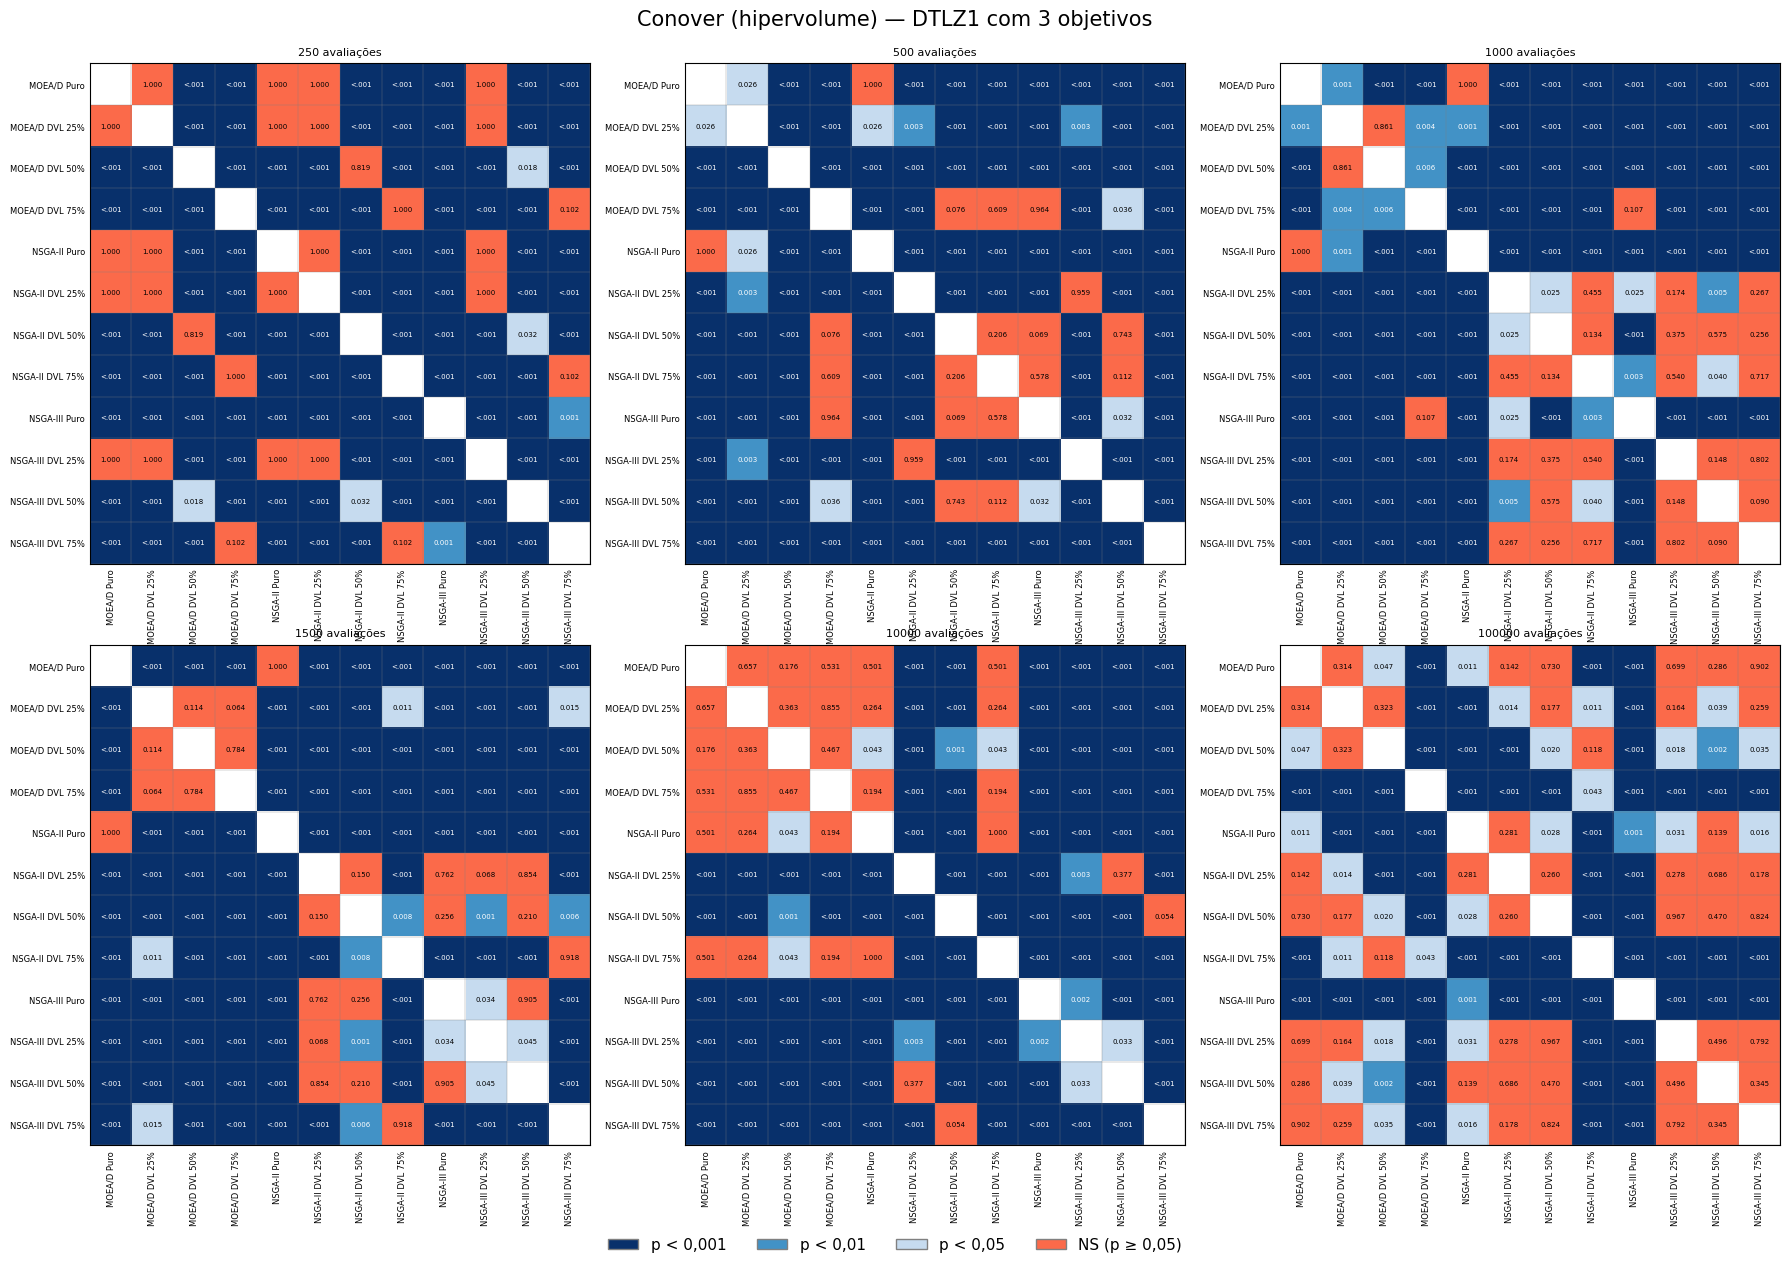


— DTLZ1 com 10 objetivos —


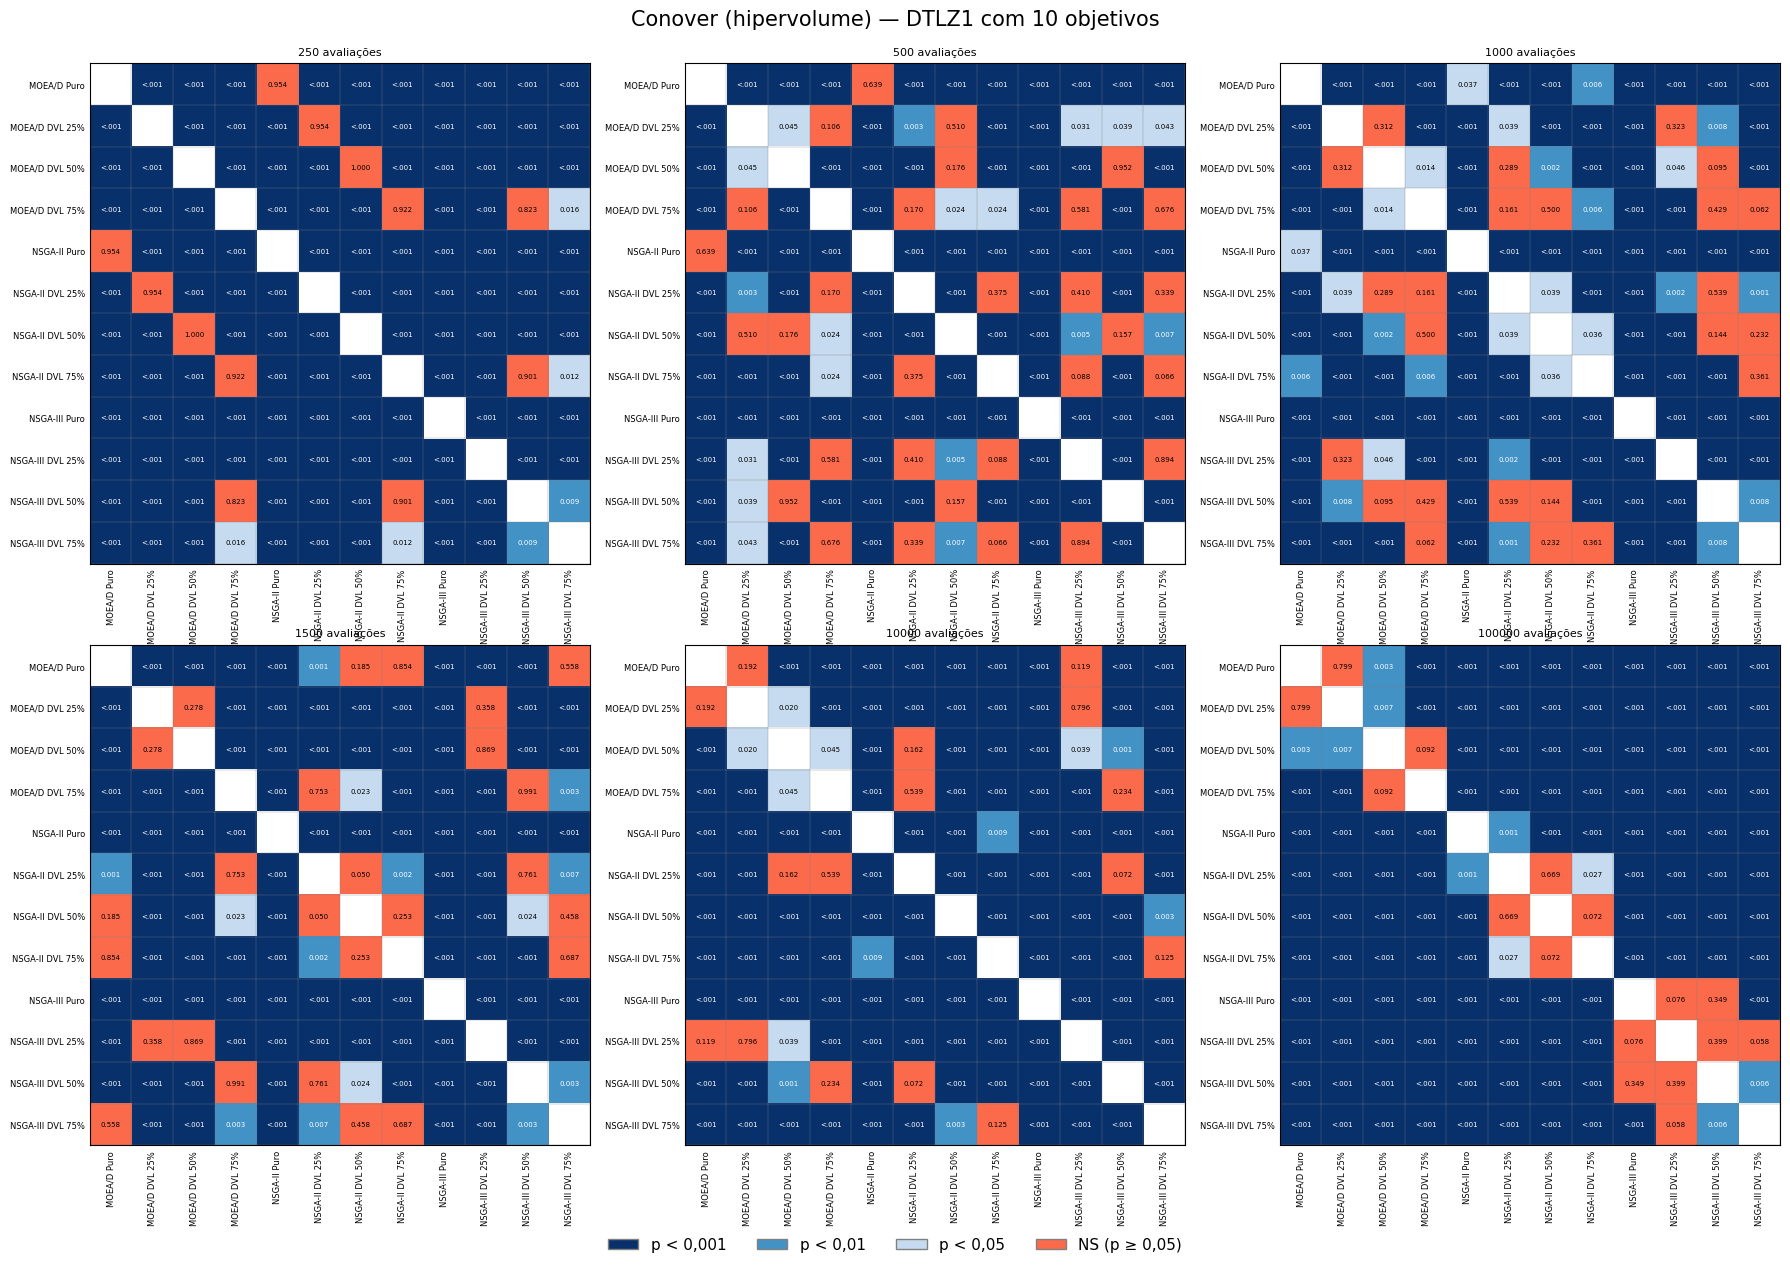


— DTLZ2 com 3 objetivos —


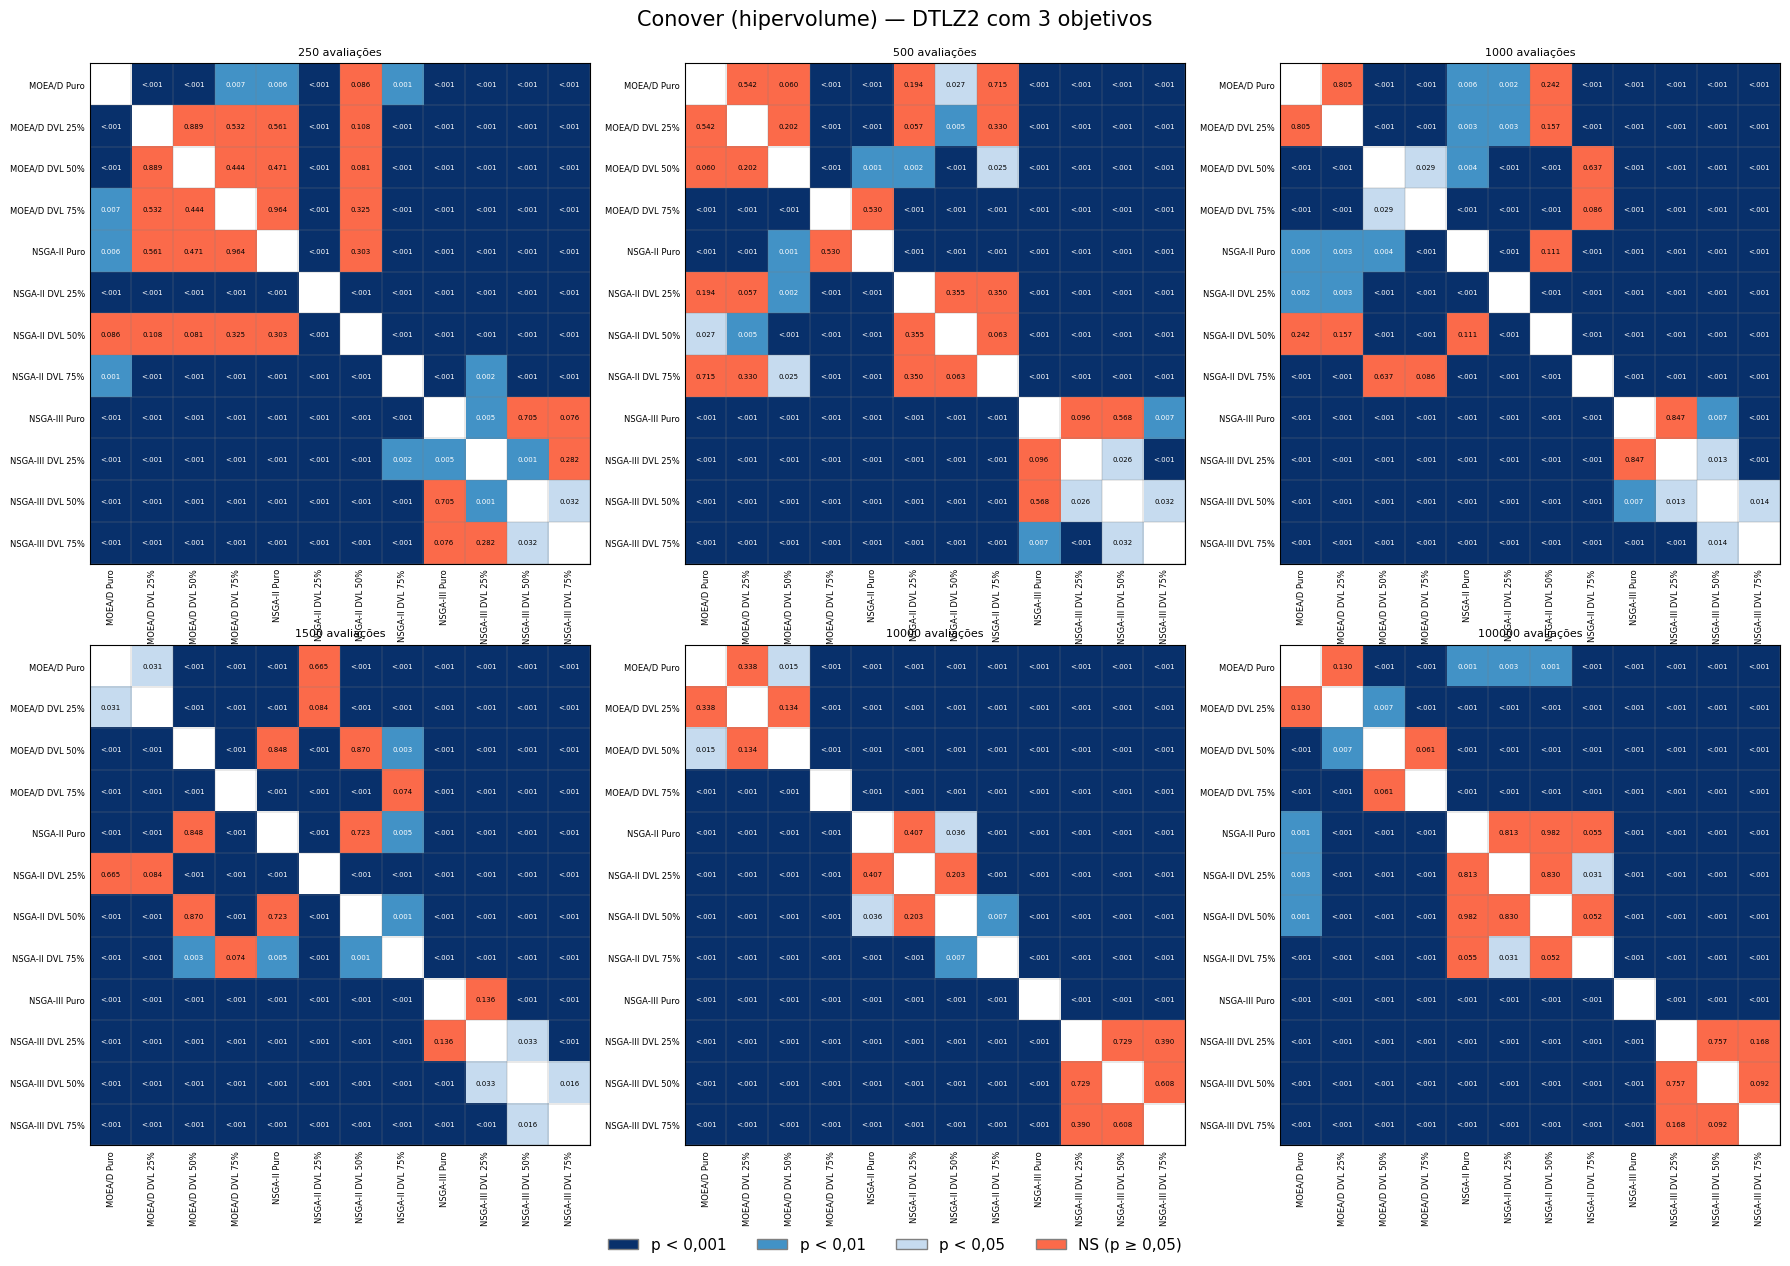


— DTLZ2 com 10 objetivos —


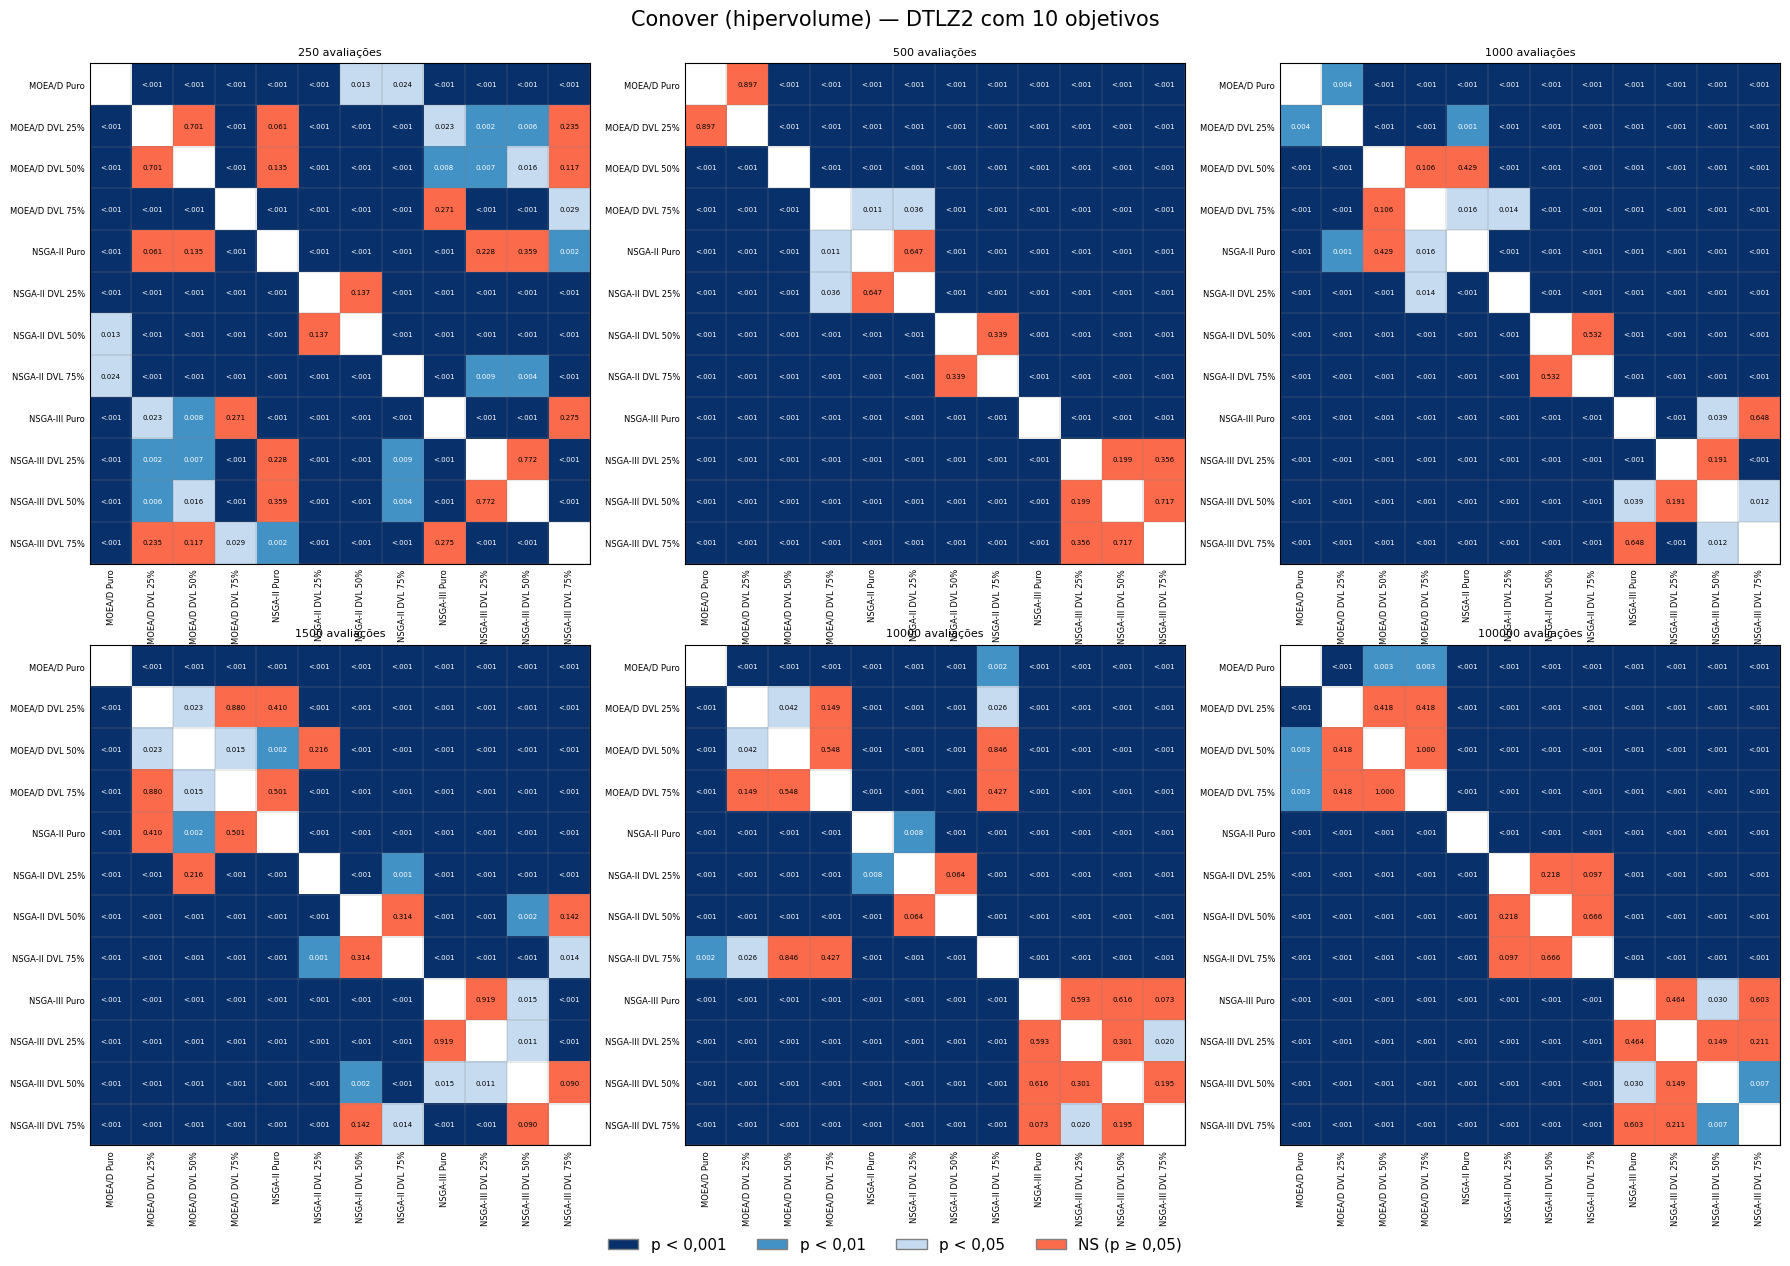


— DTLZ3 com 3 objetivos —


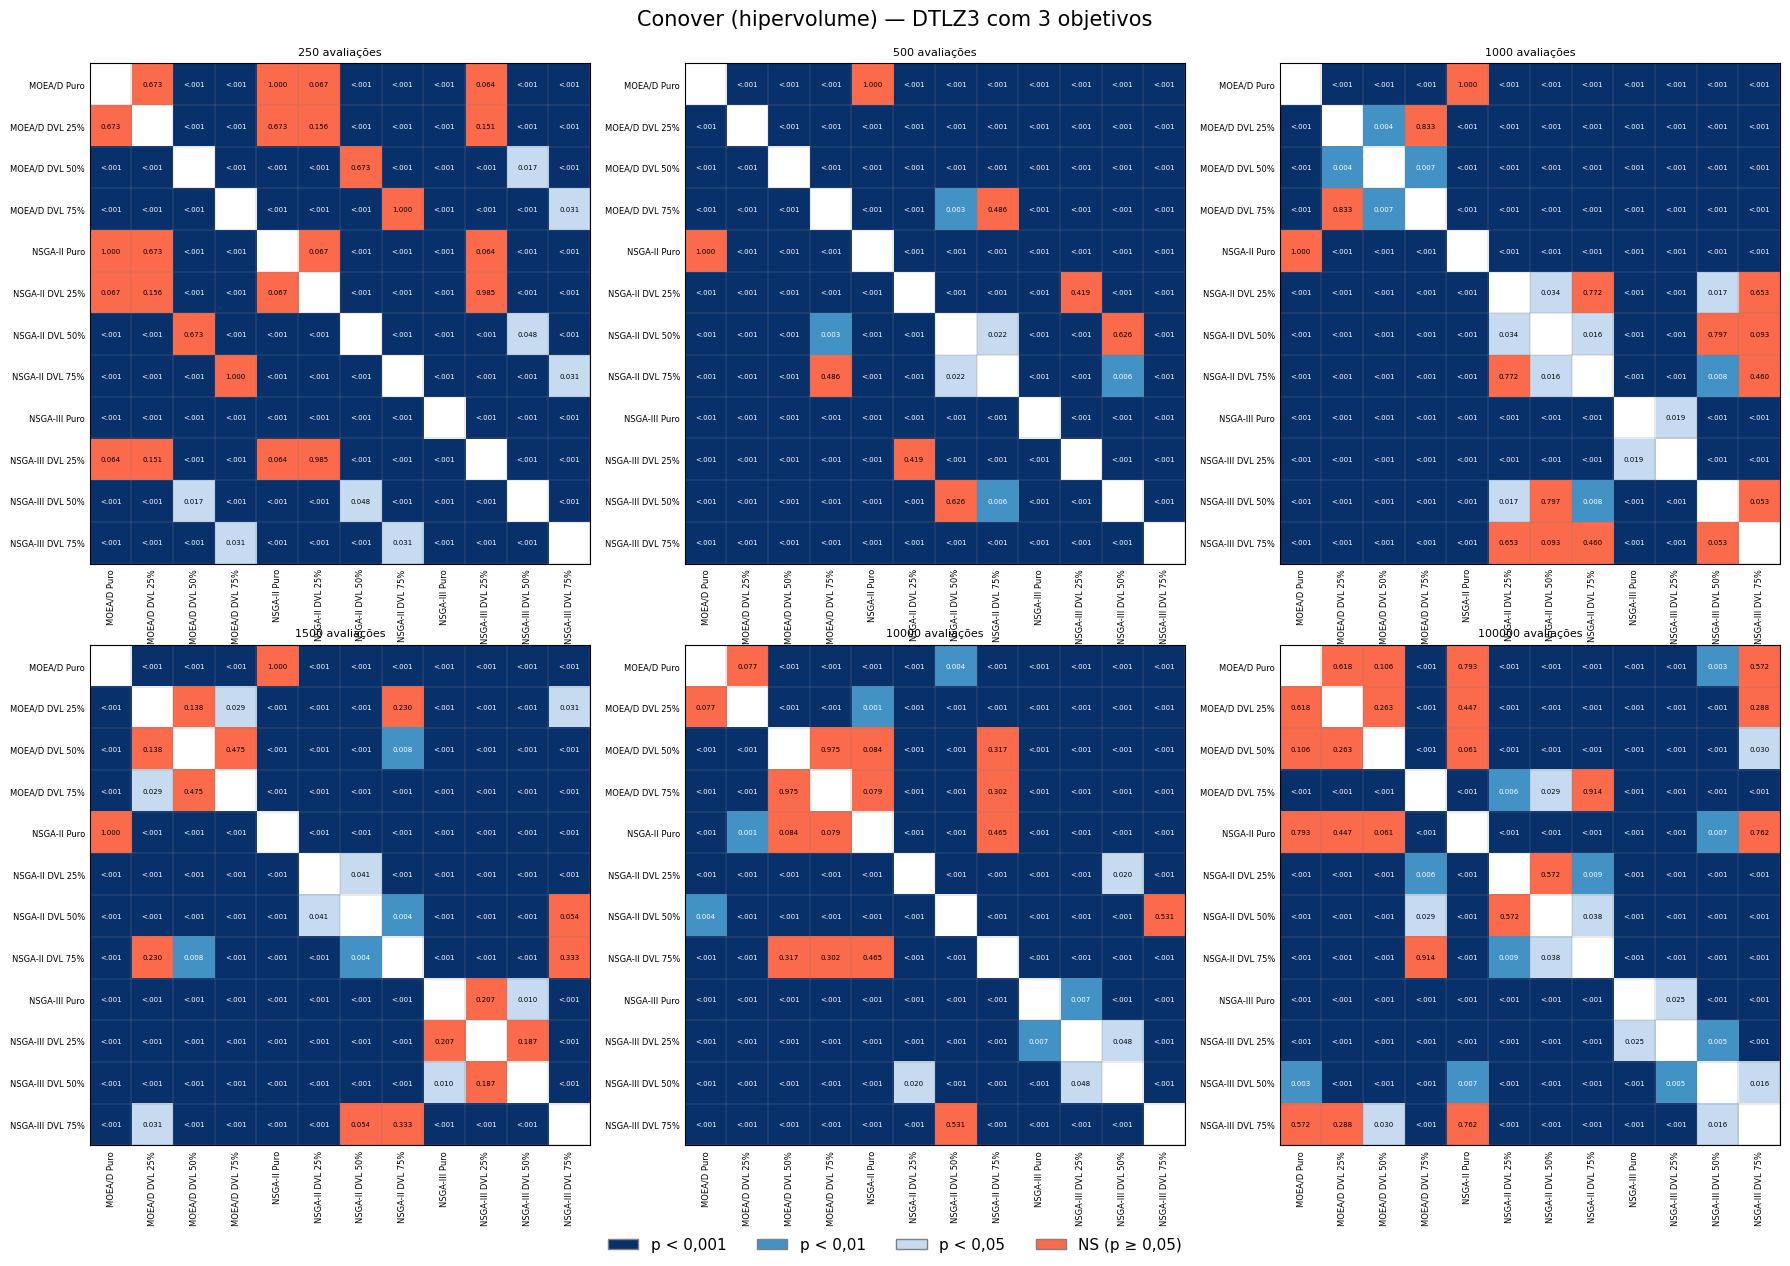


— DTLZ3 com 10 objetivos —


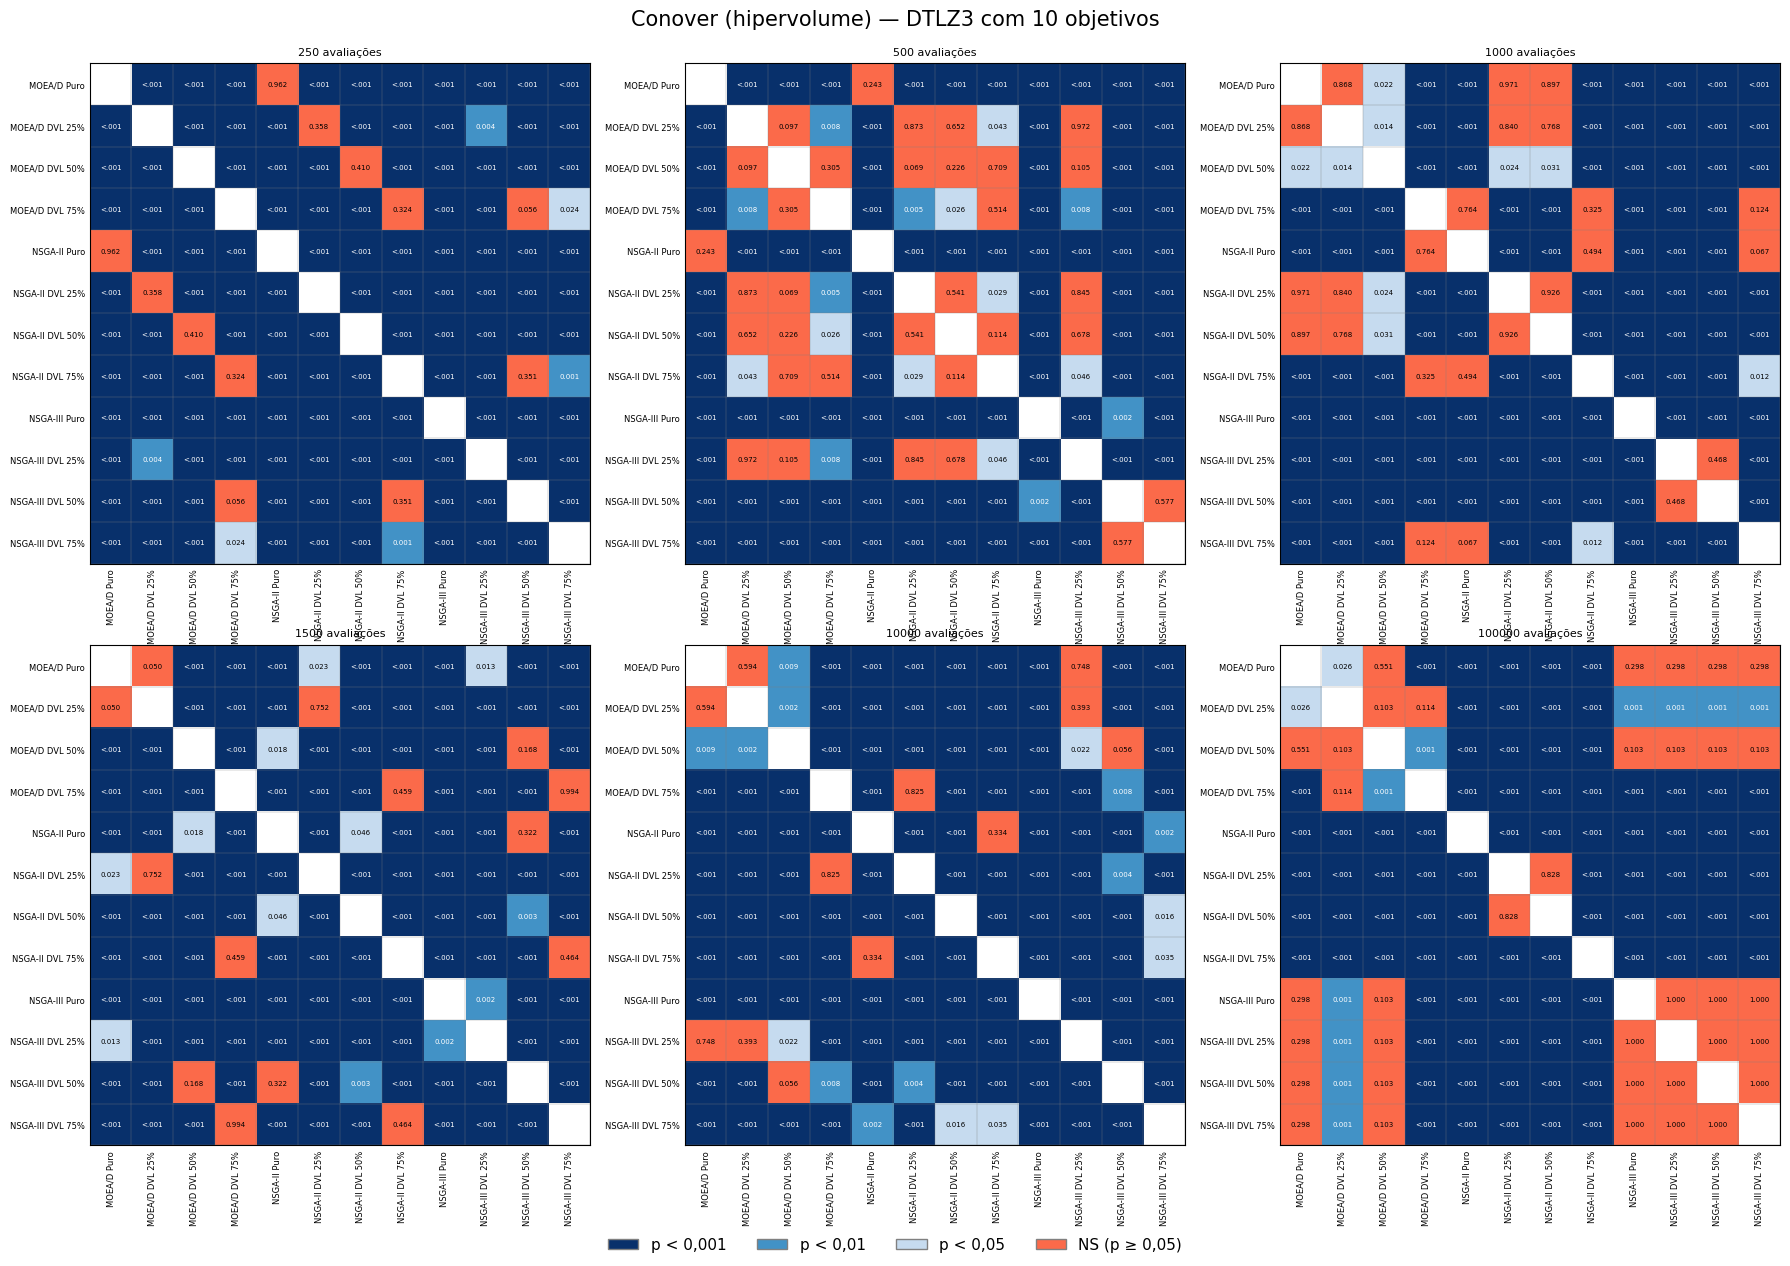


— DTLZ4 com 3 objetivos —


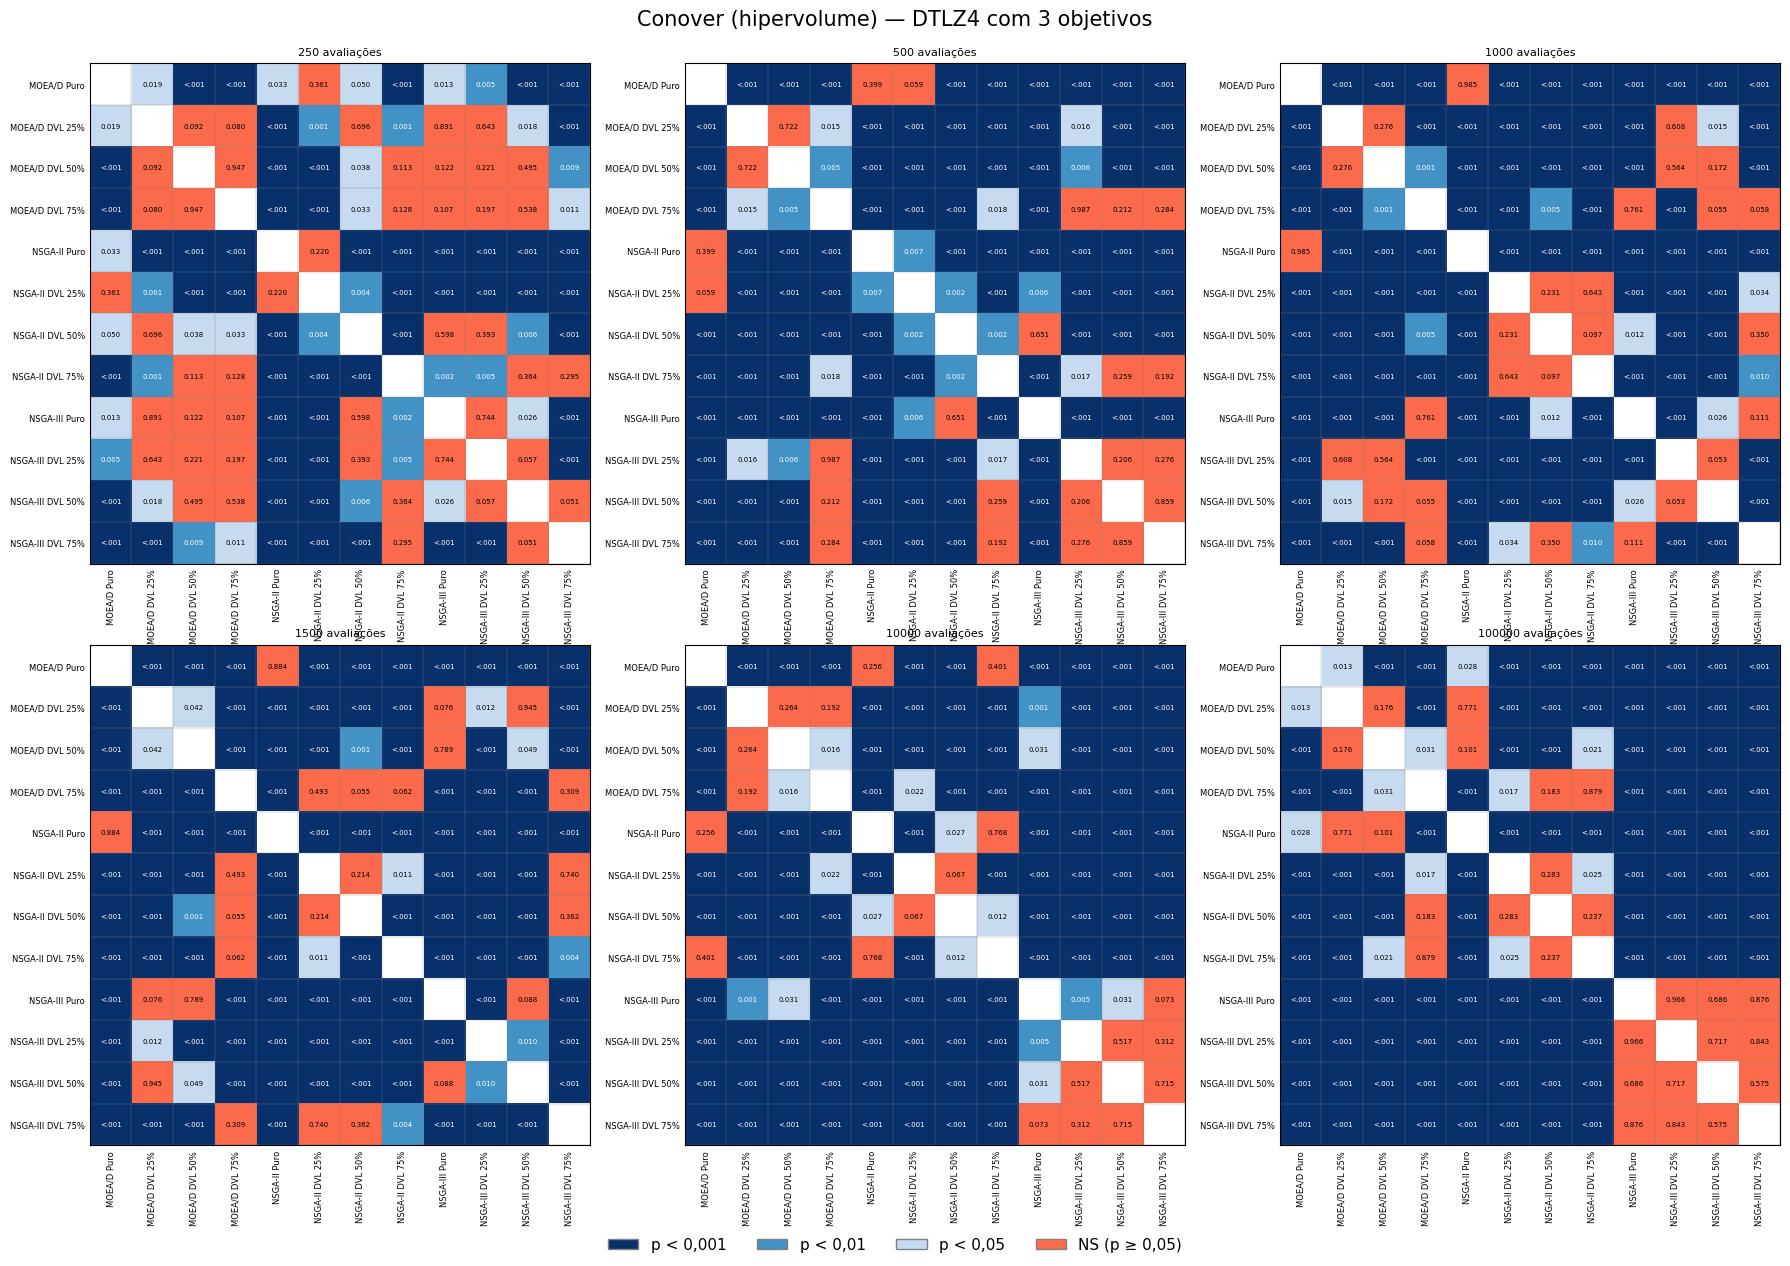


— DTLZ4 com 10 objetivos —


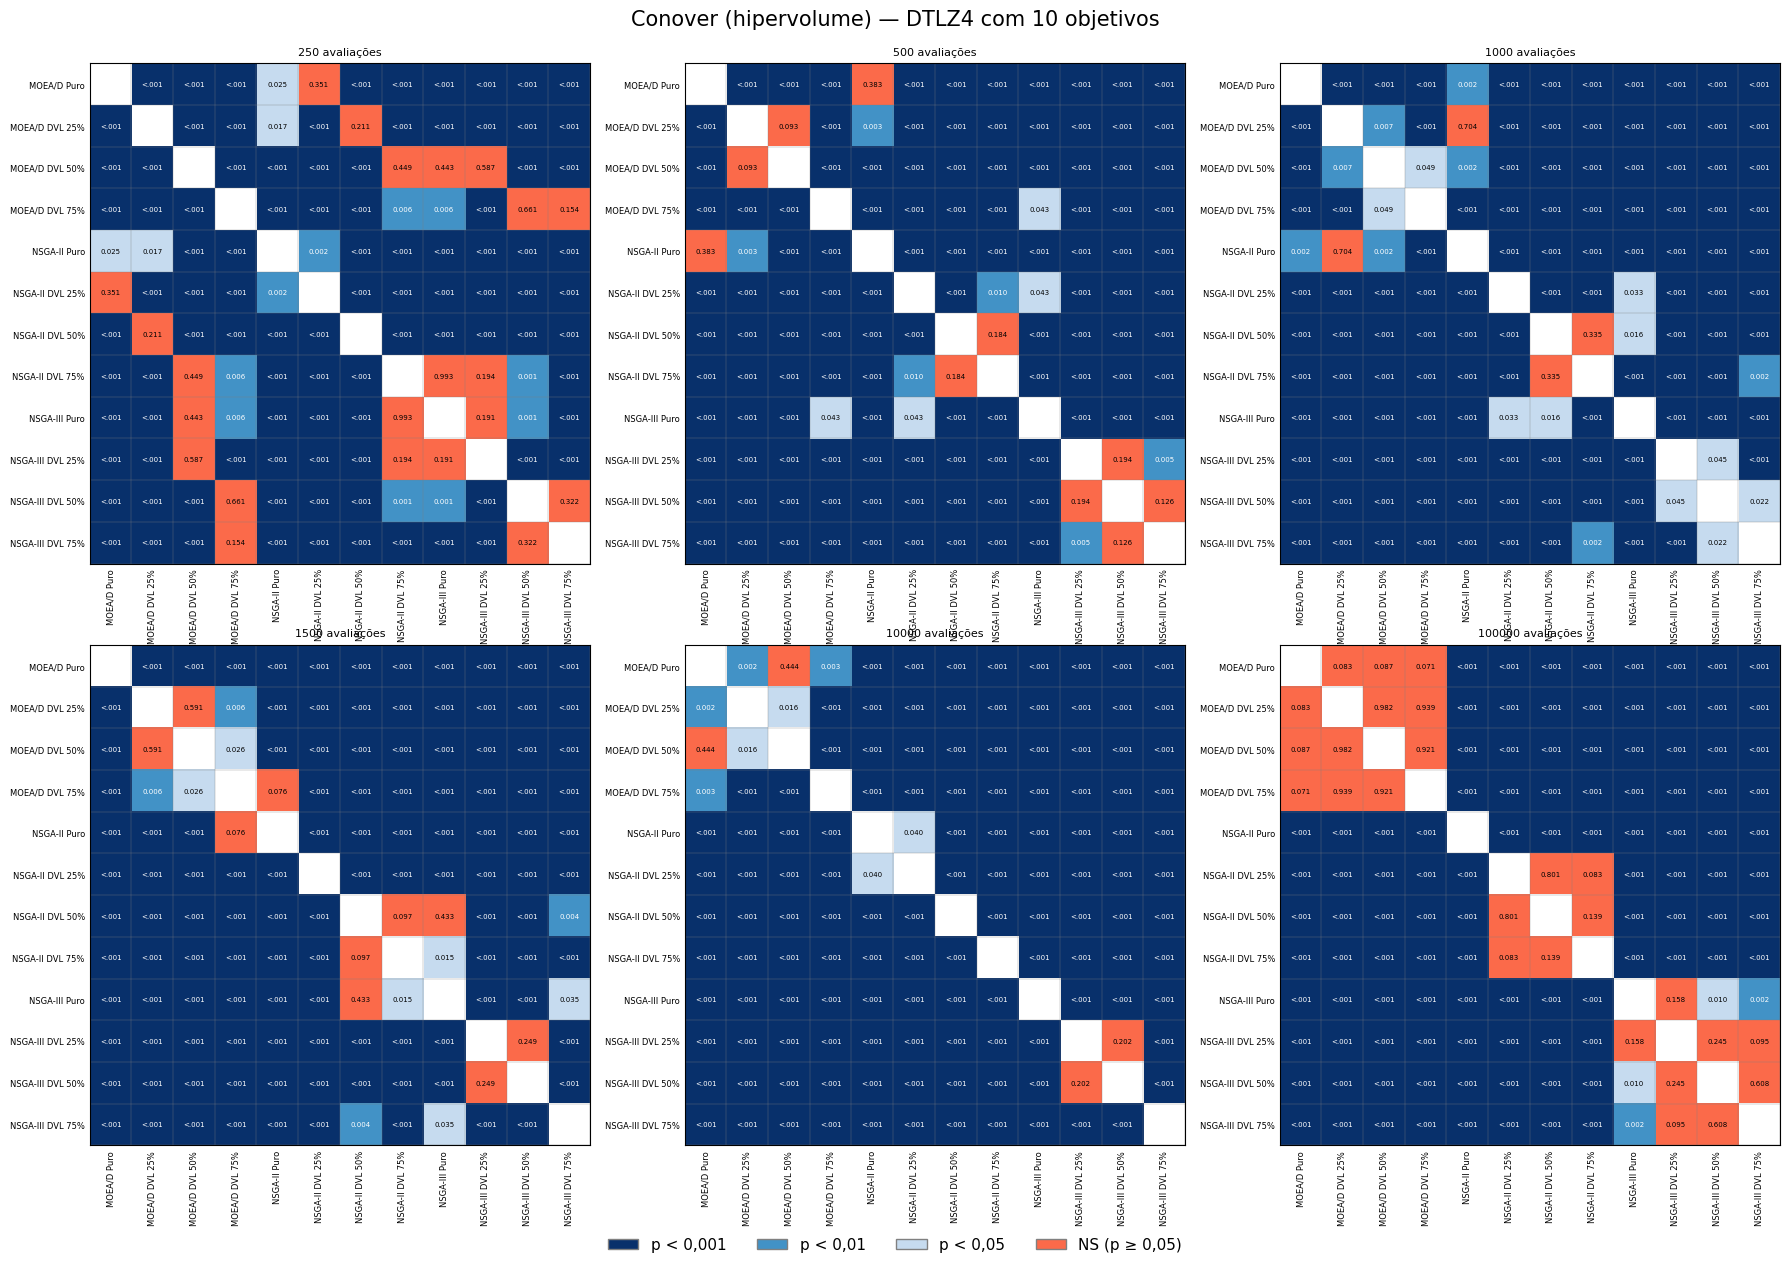

In [20]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

HEATMAP_DIR = "out/heatmaps"

# Paleta do Artur: [diagonal, NS (p>=.05), p<.001, p<.01, p<.05].
CONOVER_CMAP = ["1", "#fb6a4a", "#08306b", "#4292c6", "#c6dbef"]
_LEGEND = [("p < 0,001", "#08306b"), ("p < 0,01", "#4292c6"),
           ("p < 0,05", "#c6dbef"), ("NS (p ≥ 0,05)", "#fb6a4a")]


def _conover_cat(pc):
    '''Mapeia p-values -> índice de cor (0=diag, 1=NS, 2=<.001, 3=<.01, 4=<.05).'''
    x = pc.values.astype(float)
    cat = np.full(x.shape, 1.0)
    cat[x < 0.05] = 4
    cat[x < 0.01] = 3
    cat[x < 0.001] = 2
    np.fill_diagonal(cat, 0.0)
    return cat


def conover_heatmap(pc, ax, annotate=True, fontsize=6, title=None):
    '''Heatmap de Conover (paleta do Artur) com o p-value escrito em cada quadrado.'''
    cat = _conover_cat(pc)
    ax.imshow(cat, cmap=ListedColormap(CONOVER_CMAP), vmin=-0.5, vmax=4.5, aspect="equal")
    n = len(pc)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(pc.columns, rotation=90, fontsize=fontsize)
    ax.set_yticklabels(pc.index, fontsize=fontsize)
    ax.set_xticks(np.arange(-0.5, n), minor=True)
    ax.set_yticks(np.arange(-0.5, n), minor=True)
    ax.grid(which="minor", color="0.5", linewidth=0.25)
    ax.tick_params(which="both", length=0)
    if annotate:
        for i in range(n):
            for j in range(n):
                if i == j:
                    continue
                p = pc.values[i, j]
                s = "<.001" if p < 0.001 else f"{p:.3f}"
                color = "white" if cat[i, j] in (2.0, 3.0) else "black"
                ax.text(j, i, s, ha="center", va="center",
                        fontsize=fontsize - 1, color=color)
    if title:
        ax.set_title(title, fontsize=fontsize + 2)


def _legend_handles():
    return [Patch(facecolor=c, edgecolor="0.5", label=l) for l, c in _LEGEND]


def save_individual_heatmaps(rows, metric_tag, annotate=True):
    '''Salva um heatmap anotado por instância em out/heatmaps/<metric_tag>/.'''
    outdir = os.path.join(HEATMAP_DIR, metric_tag)
    os.makedirs(outdir, exist_ok=True)
    for (problem, m, evals), res in sorted(rows.items()):
        fig, ax = plt.subplots(figsize=(8, 7))
        conover_heatmap(res["conover"], ax, annotate=annotate, fontsize=7,
                        title=f"{metric_tag.upper()} — {problem}, M={m}, {evals} aval.")
        ax.legend(handles=_legend_handles(), bbox_to_anchor=(1.02, 1.0),
                  loc="upper left", fontsize=8, frameon=False)
        fig.savefig(os.path.join(outdir, f"{problem}_m{m}_e{evals}.png"),
                    dpi=130, bbox_inches="tight")
        plt.close(fig)


def plot_problem_grid(rows, problem, m, metric_tag, annotate=True, show=False):
    '''Grade das 6 avaliações para um (problema, M). Layout 2x3.
    Salva GRID_<problema>_m<M>.png.'''
    evals_list = sorted({k[2] for k in rows if k[0] == problem and k[1] == m})
    ncol = 3
    nrow = int(np.ceil(len(evals_list) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(6.0 * ncol, 6.4 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for c, e in enumerate(evals_list):
        res = rows.get((problem, m, e))
        conover_heatmap(res["conover"], axes[c], annotate=annotate,
                        fontsize=6, title=f"{e} avaliações")
    for ax in axes[len(evals_list):]:
        ax.axis("off")
    fig.legend(handles=_legend_handles(), loc="lower center", ncol=4,
               fontsize=11, frameon=False)
    fig.suptitle(f"Conover ({metric_tag}) — {problem} com {m} objetivos", fontsize=15)
    fig.tight_layout(rect=[0, 0.03, 1, 0.98])
    outdir = os.path.join(HEATMAP_DIR, metric_tag)
    os.makedirs(outdir, exist_ok=True)
    fig.savefig(os.path.join(outdir, f"GRID_{problem}_m{m}.png"),
                dpi=130, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


print("Salvando heatmaps individuais (com p-value nos quadrados)...")
save_individual_heatmaps(hv_rows, "hipervolume")
save_individual_heatmaps(tm_rows, "tempo")
print(f"Salvos em {HEATMAP_DIR}/<métrica>/")

print("Gerando grades de Tempo (salvas em disco)...")
for prob in sorted({k[0] for k in tm_rows}):
    for mm in sorted({k[1] for k in tm_rows if k[0] == prob}):
        plot_problem_grid(tm_rows, prob, mm, "tempo", show=False)
print(f"Grades de tempo salvas em {HEATMAP_DIR}/tempo/GRID_<problema>_m<M>.png")

# Exibe inline TODAS as grades de Hipervolume, unificadas por problema e objetivo.
print("\nHeatmaps unificados por problema e nº de objetivos (Hipervolume):")
for prob in sorted({k[0] for k in hv_rows}):
    for mm in sorted({k[1] for k in hv_rows if k[0] == prob}):
        print(f"\n— {prob} com {mm} objetivos —")
        plot_problem_grid(hv_rows, prob, mm, "hipervolume", show=True)

## 4. Tabela consolidada (estilo Tabelas 19/20 do Artur)

Uma tabela por número de objetivos (**M=3** e **M=10**), no formato das Tabelas 19/20 do
Artur: **problemas à esquerda** (DTLZ1–4), **uma linha por quantidade de avaliações**
(250 … 100000) e **os métodos nas colunas** — as 3 MOEAs agrupadas, cada uma com suas 4
variações (Puro, DVL 25/50/75%). As células trazem `(média ± desvio)·10^x`, com **negrito**
na melhor média da instância e nas estatisticamente equivalentes (Conover $p\ge0{,}05$).
LaTeX em `sidewaystable` (requer `rotating`, `booktabs`, `multirow`).

In [21]:
VAR_SHORT = {"Puro": "Puro", "DVL 25%": "25%", "DVL 50%": "50%", "DVL 75%": "75%"}


def _artur_cell(mean, std, bold, style, latex):
    if style == "exp":  # formato do Artur: (m.mm ± s.ss)e±X
        ref = mean if mean > 0 else (std if std > 0 else 0.0)
        exp = int(np.floor(np.log10(ref))) if ref > 0 else 0
        mm, ss = mean / 10 ** exp, std / 10 ** exp
        if round(mm, 2) >= 10.0:  # mantissa arredondou p/ 10.00 -> sobe o expoente
            exp += 1
            mm, ss = mean / 10 ** exp, std / 10 ** exp
        if latex:
            body = f"({mm:.2f} \\pm {ss:.2f})\\mathrm{{e}}{{{exp:+d}}}"
            return f"$\\mathbf{{{body}}}$" if bold else f"${body}$"
        body = f"({mm:.2f}±{ss:.2f})e{exp:+d}"
        return f"**{body}**" if bold else body
    else:  # tempo: segundos com 2 casas
        if latex:
            body = f"{mean:.2f} \\pm {std:.2f}"
            return f"$\\mathbf{{{body}}}$" if bold else f"${body}$"
        body = f"{mean:.2f}±{std:.2f}"
        return f"**{body}**" if bold else body


def build_consolidated_table(rows, m, metric_label, style, latex_label):
    '''Tabela única (estilo Tabelas 19/20 do Artur) por número de objetivos:
    problemas à esquerda, linha = nº de avaliações, colunas = 12 métodos.'''
    problems = sorted({k[0] for k in rows if k[1] == m})
    evals_list = sorted({k[2] for k in rows if k[1] == m})

    # --- Markdown (cabeçalho plano com as 12 colunas) ---
    header = ["Problema", "Aval."] + CONFIG_ORDER
    md_lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
    for problem in problems:
        for ei, e in enumerate(evals_list):
            res = rows[(problem, m, e)]
            cells = [problem if ei == 0 else "", str(e)]
            for cfg in CONFIG_ORDER:
                cells.append(_artur_cell(res["means"][cfg], res["stds"][cfg],
                                         cfg in res["bold"], style, latex=False))
            md_lines.append("| " + " | ".join(cells) + " |")
    display(Markdown(f"#### {metric_label} — M={m}\n" + "\n".join(md_lines)))

    # --- LaTeX (sidewaystable, cabeçalho agrupado por algoritmo) ---
    tex = [r"\begin{sidewaystable}[ht]", r"  \centering", r"  \footnotesize",
           f"  \\caption{{{metric_label} (média e desvio padrão) para {m} objetivos. "
           f"Negrito = melhor média e equivalentes (Conover $p\\ge0{{,}}05$).}}",
           f"  \\label{{tab:{latex_label}_m{m}}}",
           r"  \begin{tabular}{ll" + "c" * len(CONFIG_ORDER) + r"}", r"    \toprule",
           "    & & " + " & ".join(f"\\multicolumn{{{len(VAR_ORDER)}}}{{c}}{{{a}}}"
                                   for a in ALGO_ORDER) + r" \\",
           "    Problema & Aval. & "
           + " & ".join(VAR_SHORT[v].replace("%", r"\%")
                        for _ in ALGO_ORDER for v in VAR_ORDER) + r" \\",
           r"    \midrule"]
    for pi, problem in enumerate(problems):
        for ei, e in enumerate(evals_list):
            res = rows[(problem, m, e)]
            head = f"\\multirow{{{len(evals_list)}}}{{*}}{{{problem}}}" if ei == 0 else ""
            cells = [head, str(e)]
            for cfg in CONFIG_ORDER:
                cells.append(_artur_cell(res["means"][cfg], res["stds"][cfg],
                                         cfg in res["bold"], style, latex=True))
            tex.append("    " + " & ".join(cells) + r" \\")
        if pi != len(problems) - 1:
            tex.append(r"    \midrule")
    tex += [r"    \bottomrule", r"  \end{tabular}", r"\end{sidewaystable}"]
    print("\n".join(tex)); print()


for _m in sorted(df.m.unique()):
    build_consolidated_table(hv_rows, _m, "Hipervolume", style="exp",
                             latex_label="hv_consolidado")

#### Hipervolume — M=3
| Problema | Aval. | MOEA/D Puro | MOEA/D DVL 25% | MOEA/D DVL 50% | MOEA/D DVL 75% | NSGA-II Puro | NSGA-II DVL 25% | NSGA-II DVL 50% | NSGA-II DVL 75% | NSGA-III Puro | NSGA-III DVL 25% | NSGA-III DVL 50% | NSGA-III DVL 75% |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| DTLZ1 | 250 | (0.00±0.00)e+0 | (0.00±0.00)e+0 | (4.11±6.88)e-2 | (2.98±1.04)e-1 | (0.00±0.00)e+0 | (0.00±0.00)e+0 | (5.21±7.75)e-2 | (2.98±1.04)e-1 | **(5.26±1.24)e-1** | (0.00±0.00)e+0 | (7.46±8.77)e-2 | (3.41±1.09)e-1 |
|  | 500 | (0.00±0.00)e+0 | (4.33±7.86)e-2 | (4.55±1.58)e-1 | (5.62±0.05)e-1 | (0.00±0.00)e+0 | (1.07±0.83)e-1 | (5.65±0.71)e-1 | (5.68±0.20)e-1 | (5.37±1.14)e-1 | (1.04±0.84)e-1 | (5.69±0.70)e-1 | **(6.11±0.18)e-1** |
|  | 1000 | (0.00±0.00)e+0 | (3.03±2.82)e-1 | (4.00±2.58)e-1 | (5.76±0.21)e-1 | (0.00±0.00)e+0 | (6.18±0.67)e-1 | **(6.52±0.29)e-1** | (6.34±0.24)e-1 | (5.75±1.00)e-1 | **(6.47±0.85)e-1** | **(6.57±0.31)e-1** | **(6.37±0.21)e-1** |
|  | 1500 | (0.00±0.00)e+0 | (4.65±2.83)e-1 | (4.40±2.65)e-1 | (5.37±1.27)e-1 | (0.00±0.00)e+0 | **(7.03±0.23)e-1** | (6.84±0.23)e-1 | (6.47±0.30)e-1 | (7.55±1.82)e-1 | **(7.69±1.04)e-1** | (7.08±0.73)e-1 | (6.47±0.26)e-1 |
|  | 10000 | (1.73±7.47)e-3 | (4.82±21.50)e-2 | (1.30±3.19)e-1 | (8.56±26.34)e-2 | (0.00±0.00)e+0 | (6.58±2.59)e-1 | (1.36±1.66)e-1 | (0.00±0.00)e+0 | **(9.93±0.10)e-1** | (8.97±0.92)e-1 | (7.57±2.49)e-1 | (3.32±3.26)e-1 |
|  | 100000 | (9.67±0.00)e-1 | (9.67±0.00)e-1 | (9.43±0.70)e-1 | (7.14±2.96)e-1 | (9.69±0.01)e-1 | (9.68±0.02)e-1 | (9.67±0.02)e-1 | (9.61±0.06)e-1 | **(9.97±0.09)e-1** | (9.64±0.43)e-1 | (9.70±0.39)e-1 | (9.58±0.53)e-1 |
| DTLZ2 | 250 | (7.29±0.47)e-1 | (6.85±0.52)e-1 | (6.78±0.67)e-1 | (6.96±0.48)e-1 | (6.96±0.22)e-1 | (5.84±1.11)e-1 | (7.08±0.46)e-1 | (7.73±0.35)e-1 | **(8.79±0.35)e-1** | (8.26±0.62)e-1 | **(8.87±0.43)e-1** | (8.43±0.40)e-1 |
|  | 500 | (8.44±0.24)e-1 | (8.38±0.32)e-1 | (8.27±0.41)e-1 | (7.85±0.45)e-1 | (8.08±0.16)e-1 | (8.52±0.20)e-1 | (8.60±0.22)e-1 | (8.46±0.23)e-1 | **(9.53±0.22)e-1** | **(9.69±0.11)e-1** | (9.47±0.22)e-1 | (9.21±0.18)e-1 |
|  | 1000 | (8.95±0.12)e-1 | (8.93±0.22)e-1 | (8.57±0.39)e-1 | (8.45±0.29)e-1 | (8.86±0.08)e-1 | (9.05±0.09)e-1 | (8.90±0.15)e-1 | (8.68±0.16)e-1 | **(9.80±0.11)e-1** | **(9.79±0.12)e-1** | (9.61±0.11)e-1 | (9.37±0.20)e-1 |
|  | 1500 | (9.11±0.04)e-1 | (9.06±0.13)e-1 | (8.94±0.19)e-1 | (8.61±0.32)e-1 | (9.00±0.05)e-1 | (9.10±0.06)e-1 | (8.98±0.12)e-1 | (8.83±0.20)e-1 | **(9.91±0.06)e-1** | **(9.81±0.10)e-1** | (9.63±0.13)e-1 | (9.41±0.07)e-1 |
|  | 10000 | (9.22±0.00)e-1 | (9.22±0.00)e-1 | (9.21±0.01)e-1 | (9.20±0.01)e-1 | (9.18±0.03)e-1 | (9.17±0.04)e-1 | (9.16±0.04)e-1 | (9.13±0.04)e-1 | **(9.98±0.01)e-1** | (9.84±0.05)e-1 | (9.82±0.07)e-1 | (9.81±0.07)e-1 |
|  | 100000 | (9.21±0.00)e-1 | (9.21±0.00)e-1 | (9.21±0.00)e-1 | (9.21±0.00)e-1 | (9.19±0.02)e-1 | (9.19±0.02)e-1 | (9.19±0.02)e-1 | (9.18±0.02)e-1 | **(9.98±0.01)e-1** | (9.90±0.05)e-1 | (9.91±0.05)e-1 | (9.86±0.06)e-1 |
| DTLZ3 | 250 | (0.00±0.00)e+0 | (7.05±31.55)e-4 | (4.76±0.88)e-1 | (7.00±0.64)e-1 | (0.00±0.00)e+0 | (1.47±3.61)e-2 | (4.89±1.02)e-1 | (7.00±0.64)e-1 | **(9.68±0.21)e-1** | (1.47±3.61)e-2 | (5.38±0.90)e-1 | (7.25±0.64)e-1 |
|  | 500 | (0.00±0.00)e+0 | (4.14±1.62)e-1 | (7.69±1.81)e-1 | (8.33±0.02)e-1 | (0.00±0.00)e+0 | (5.73±0.75)e-1 | (8.41±0.16)e-1 | (8.36±0.08)e-1 | **(9.76±0.13)e-1** | (5.99±0.85)e-1 | (8.42±0.16)e-1 | (8.52±0.06)e-1 |
|  | 1000 | (0.00±0.00)e+0 | (6.61±3.34)e-1 | (7.29±3.11)e-1 | (7.12±3.07)e-1 | (0.00±0.00)e+0 | (8.64±0.20)e-1 | (8.71±0.15)e-1 | (8.62±0.06)e-1 | **(9.81±0.10)e-1** | (9.26±0.33)e-1 | (8.71±0.12)e-1 | (8.63±0.08)e-1 |
|  | 1500 | (0.00±0.00)e+0 | (6.22±4.20)e-1 | (6.21±3.94)e-1 | (7.87±1.95)e-1 | (0.00±0.00)e+0 | (8.99±0.20)e-1 | (8.81±0.12)e-1 | (8.67±0.09)e-1 | **(9.91±0.07)e-1** | **(9.81±0.16)e-1** | (9.60±0.32)e-1 | (8.71±0.10)e-1 |
|  | 10000 | (5.22±4.14)e-1 | (3.83±4.02)e-1 | (4.96±22.18)e-2 | (4.70±20.62)e-2 | (1.60±2.46)e-1 | (9.60±0.47)e-1 | (8.43±1.20)e-1 | (5.46±12.51)e-2 | **(1.00±0.00)e+0** | (9.95±0.11)e-1 | (9.86±0.22)e-1 | (8.61±1.36)e-1 |
|  | 100000 | (9.99±0.00)e-1 | (9.99±0.00)e-1 | (9.99±0.00)e-1 | (9.97±0.02)e-1 | (9.99±0.00)e-1 | (9.99±0.00)e-1 | (9.99±0.00)e-1 | (9.99±0.01)e-1 | **(1.00±0.00)e+0** | (1.00±0.00)e+0 | (1.00±0.00)e+0 | (9.99±0.02)e-1 |
| DTLZ4 | 250 | (5.30±0.97)e-1 | (6.09±1.26)e-1 | (6.69±1.23)e-1 | (6.68±1.02)e-1 | (4.43±0.55)e-1 | (4.24±2.26)e-1 | (6.10±0.79)e-1 | **(7.13±0.62)e-1** | (6.19±1.35)e-1 | (6.16±1.60)e-1 | **(6.91±0.74)e-1** | **(7.40±0.57)e-1** |
|  | 500 | (6.37±1.32)e-1 | **(8.74±0.30)e-1** | **(8.77±0.21)e-1** | (8.59±0.22)e-1 | (6.10±0.87)e-1 | (7.50±0.46)e-1 | (8.16±0.26)e-1 | (8.47±0.14)e-1 | (7.80±0.93)e-1 | (8.59±0.29)e-1 | (8.50±0.26)e-1 | (8.54±0.14)e-1 |
|  | 1000 | (6.78±1.53)e-1 | **(9.14±0.03)e-1** | **(9.12±0.04)e-1** | (9.05±0.05)e-1 | (7.67±1.20)e-1 | (8.93±0.11)e-1 | (8.98±0.06)e-1 | (8.93±0.06)e-1 | (8.79±0.84)e-1 | **(9.20±0.16)e-1** | **(9.09±0.06)e-1** | (9.00±0.05)e-1 |
|  | 1500 | (6.90±1.63)e-1 | (9.20±0.01)e-1 | (9.18±0.01)e-1 | (9.13±0.02)e-1 | (8.07±1.23)e-1 | (9.13±0.04)e-1 | (9.15±0.02)e-1 | (9.09±0.04)e-1 | (9.12±0.70)e-1 | **(9.28±0.08)e-1** | (9.20±0.02)e-1 | (9.14±0.04)e-1 |
|  | 10000 | (7.35±1.65)e-1 | (9.22±0.00)e-1 | (9.23±0.00)e-1 | (9.22±0.00)e-1 | (8.57±1.01)e-1 | (9.21±0.01)e-1 | (9.20±0.01)e-1 | (9.17±0.01)e-1 | **(9.36±0.66)e-1** | (9.29±0.05)e-1 | (9.28±0.03)e-1 | **(9.29±0.06)e-1** |
|  | 100000 | (7.74±1.71)e-1 | (9.21±0.00)e-1 | (9.21±0.00)e-1 | (9.21±0.00)e-1 | (8.99±0.94)e-1 | (9.22±0.01)e-1 | (9.22±0.01)e-1 | (9.22±0.01)e-1 | **(9.48±0.48)e-1** | **(9.29±0.05)e-1** | **(9.27±0.01)e-1** | **(9.28±0.01)e-1** |

\begin{sidewaystable}[ht]
  \centering
  \footnotesize
  \caption{Hipervolume (média e desvio padrão) para 3 objetivos. Negrito = melhor média e equivalentes (Conover $p\ge0{,}05$).}
  \label{tab:hv_consolidado_m3}
  \begin{tabular}{llcccccccccccc}
    \toprule
    & & \multicolumn{4}{c}{MOEA/D} & \multicolumn{4}{c}{NSGA-II} & \multicolumn{4}{c}{NSGA-III} \\
    Problema & Aval. & Puro & 25\% & 50\% & 75\% & Puro & 25\% & 50\% & 75\% & Puro & 25\% & 50\% & 75\% \\
    \midrule
    \multirow{6}{*}{DTLZ1} & 250 & $(0.00 \pm 0.00)\mathrm{e}{+0}$ & $(0.00 \pm 0.00)\mathrm{e}{+0}$ & $(4.11 \pm 6.88)\mathrm{e}{-2}$ & $(2.98 \pm 1.04)\mathrm{e}{-1}$ & $(0.00 \pm 0.00)\mathrm{e}{+0}$ & $(0.00 \pm 0.00)\mathrm{e}{+0}$ & $(5.21 \pm 7.75)\mathrm{e}{-2}$ & $(2.98 \pm 1.04)\mathrm{e}{-1}$ & $\mathbf{(5.26 \pm 1.24)\mathrm{e}{-1}}$ & $(0.00 \pm 0.00)\mathrm{e}{+0}$ & $(7.46 \pm 8.77)\mathrm{e}{-2}$ & $(3.41 \pm 1.09)\mathrm{e}{-1}$ \\
     & 500 & $(0.00 \pm 0.00)\mathrm{e}{+0}$ & $(4.33 \pm 7.86)\m

#### Hipervolume — M=10
| Problema | Aval. | MOEA/D Puro | MOEA/D DVL 25% | MOEA/D DVL 50% | MOEA/D DVL 75% | NSGA-II Puro | NSGA-II DVL 25% | NSGA-II DVL 50% | NSGA-II DVL 75% | NSGA-III Puro | NSGA-III DVL 25% | NSGA-III DVL 50% | NSGA-III DVL 75% |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| DTLZ1 | 250 | (1.85±8.27)e-4 | (3.13±2.07)e-1 | (7.83±1.25)e-1 | (8.53±0.49)e-1 | (7.25±32.43)e-3 | (3.08±2.12)e-1 | (7.84±1.25)e-1 | (8.52±0.49)e-1 | **(9.33±0.28)e-1** | (6.03±2.02)e-1 | (8.34±1.14)e-1 | (8.76±0.40)e-1 |
|  | 500 | (9.86±17.32)e-2 | (8.81±0.74)e-1 | (9.04±0.66)e-1 | (8.42±1.48)e-1 | (2.12±5.67)e-2 | (8.63±0.39)e-1 | (8.92±0.59)e-1 | (8.13±1.78)e-1 | **(9.95±0.03)e-1** | (8.72±0.39)e-1 | (9.10±0.27)e-1 | (8.37±1.74)e-1 |
|  | 1000 | (4.16±3.46)e-1 | (8.55±2.75)e-1 | (9.26±0.29)e-1 | (9.06±0.28)e-1 | (4.90±8.07)e-2 | (9.17±0.24)e-1 | (9.00±0.27)e-1 | (8.58±0.67)e-1 | **(1.00±0.00)e+0** | (9.44±0.33)e-1 | (9.12±0.32)e-1 | (8.68±0.72)e-1 |
|  | 1500 | (5.75±4.04)e-1 | (9.38±1.35)e-1 | (9.50±0.14)e-1 | (9.13±0.54)e-1 | (1.29±1.55)e-1 | (8.94±1.27)e-1 | (8.97±0.31)e-1 | (8.39±1.87)e-1 | **(1.00±0.00)e+0** | (9.45±0.58)e-1 | (9.15±0.46)e-1 | (8.47±1.80)e-1 |
|  | 10000 | (9.73±1.13)e-1 | (9.97±0.04)e-1 | (9.93±0.09)e-1 | (9.86±0.21)e-1 | (1.04±4.64)e-3 | (9.92±0.07)e-1 | (9.70±0.14)e-1 | (8.61±0.66)e-1 | **(1.00±0.00)e+0** | (9.96±0.06)e-1 | (9.88±0.08)e-1 | (9.20±0.40)e-1 |
|  | 100000 | (1.00±0.00)e+0 | (1.00±0.00)e+0 | (1.00±0.00)e+0 | (1.00±0.00)e+0 | (3.57±15.73)e-2 | (5.71±4.10)e-1 | (6.91±3.72)e-1 | (9.00±1.22)e-1 | **(1.00±0.00)e+0** | **(1.00±0.00)e+0** | **(1.00±0.00)e+0** | (9.98±0.08)e-1 |
| DTLZ2 | 250 | (7.16±0.22)e-1 | (7.90±0.20)e-1 | (7.89±0.18)e-1 | **(8.11±0.18)e-1** | (7.80±0.14)e-1 | (5.34±0.64)e-1 | (6.41±0.43)e-1 | (7.48±0.27)e-1 | **(8.03±0.16)e-1** | (7.58±0.52)e-1 | (7.67±0.37)e-1 | (7.99±0.23)e-1 |
|  | 500 | (6.65±0.56)e-1 | (6.47±0.87)e-1 | (7.45±0.49)e-1 | (7.88±0.41)e-1 | (8.12±0.15)e-1 | (8.08±0.26)e-1 | (8.62±0.19)e-1 | (8.69±0.17)e-1 | (9.16±0.10)e-1 | **(9.86±0.05)e-1** | **(9.87±0.06)e-1** | **(9.84±0.12)e-1** |
|  | 1000 | (7.24±0.36)e-1 | (7.72±0.51)e-1 | (8.22±0.45)e-1 | (8.35±0.49)e-1 | (8.21±0.15)e-1 | (8.62±0.18)e-1 | (9.01±0.12)e-1 | (8.97±0.16)e-1 | (9.65±0.36)e-1 | **(9.83±0.29)e-1** | **(9.78±0.22)e-1** | (9.63±0.16)e-1 |
|  | 1500 | (7.48±0.30)e-1 | (8.23±0.39)e-1 | (8.47±0.49)e-1 | (8.17±0.50)e-1 | (8.17±0.17)e-1 | (8.64±0.25)e-1 | (9.09±0.21)e-1 | (8.99±0.18)e-1 | **(9.86±0.09)e-1** | **(9.77±0.52)e-1** | (9.46±1.06)e-1 | (9.37±0.46)e-1 |
|  | 10000 | (8.11±0.31)e-1 | (8.62±0.27)e-1 | (8.44±0.26)e-1 | (8.50±0.30)e-1 | (6.11±0.38)e-1 | (6.93±0.36)e-1 | (7.37±0.43)e-1 | (8.42±0.41)e-1 | **(9.79±0.88)e-1** | **(9.99±0.02)e-1** | **(9.94±0.16)e-1** | (9.85±0.33)e-1 |
|  | 100000 | (8.56±0.18)e-1 | (8.74±0.13)e-1 | (8.70±0.19)e-1 | (8.71±0.21)e-1 | (5.34±0.35)e-1 | (6.23±0.54)e-1 | (6.43±0.55)e-1 | (6.51±0.53)e-1 | **(9.99±0.01)e-1** | **(9.99±0.01)e-1** | (9.99±0.01)e-1 | **(9.99±0.01)e-1** |
| DTLZ3 | 250 | (1.91±2.28)e-1 | (6.56±1.17)e-1 | (9.17±0.23)e-1 | (9.43±0.11)e-1 | (1.79±1.97)e-1 | (6.10±1.43)e-1 | (9.14±0.22)e-1 | (9.40±0.10)e-1 | **(9.94±0.02)e-1** | (7.83±1.28)e-1 | (9.34±0.17)e-1 | (9.49±0.09)e-1 |
|  | 500 | (6.24±2.90)e-1 | (8.91±1.56)e-1 | (9.52±0.06)e-1 | (9.53±0.03)e-1 | (3.70±1.50)e-1 | (9.40±0.16)e-1 | (9.50±0.05)e-1 | (9.52±0.01)e-1 | **(9.99±0.02)e-1** | (9.42±0.15)e-1 | (9.63±0.04)e-1 | (9.62±0.04)e-1 |
|  | 1000 | (9.55±0.43)e-1 | (9.21±1.22)e-1 | (9.74±0.17)e-1 | (6.95±1.94)e-1 | (7.09±1.38)e-1 | (9.67±0.04)e-1 | (9.68±0.04)e-1 | (6.48±1.80)e-1 | **(1.00±0.00)e+0** | (9.93±0.09)e-1 | (9.91±0.11)e-1 | (8.06±0.86)e-1 |
|  | 1500 | (9.83±0.18)e-1 | (9.65±0.42)e-1 | (8.73±2.18)e-1 | (5.04±2.78)e-1 | (8.79±0.83)e-1 | (9.73±0.03)e-1 | (8.28±0.86)e-1 | (4.53±2.61)e-1 | **(1.00±0.00)e+0** | (9.98±0.01)e-1 | (9.02±0.64)e-1 | (5.26±2.55)e-1 |
|  | 10000 | (1.00±0.00)e+0 | (1.00±0.00)e+0 | (9.98±0.04)e-1 | (9.92±0.11)e-1 | (3.54±3.96)e-1 | (9.96±0.03)e-1 | (9.89±0.04)e-1 | (9.39±0.30)e-1 | **(1.00±0.00)e+0** | (1.00±0.00)e+0 | (9.99±0.02)e-1 | (9.71±0.19)e-1 |
|  | 100000 | **(1.00±0.00)e+0** | (1.00±0.00)e+0 | **(1.00±0.00)e+0** | (1.00±0.00)e+0 | (2.78±2.74)e-1 | (8.62±3.02)e-1 | (8.57±2.84)e-1 | (9.97±0.12)e-1 | **(1.00±0.00)e+0** | **(1.00±0.00)e+0** | **(1.00±0.00)e+0** | **(1.00±0.00)e+0** |
| DTLZ4 | 250 | (6.24±0.72)e-1 | (8.03±0.42)e-1 | (8.91±0.35)e-1 | **(9.27±0.25)e-1** | (7.29±0.71)e-1 | (5.33±1.28)e-1 | (8.22±0.67)e-1 | (9.00±0.36)e-1 | (8.73±1.04)e-1 | (8.79±0.56)e-1 | **(9.31±0.22)e-1** | **(9.38±0.21)e-1** |
|  | 500 | (7.71±0.49)e-1 | (8.33±0.36)e-1 | (8.52±0.61)e-1 | (9.20±0.31)e-1 | (7.87±0.43)e-1 | (9.53±0.14)e-1 | (9.67±0.12)e-1 | (9.63±0.11)e-1 | (9.35±0.31)e-1 | **(9.93±0.03)e-1** | **(9.91±0.03)e-1** | (9.89±0.02)e-1 |
|  | 1000 | (8.37±0.48)e-1 | (8.84±0.35)e-1 | (9.09±0.18)e-1 | (9.29±0.24)e-1 | (8.82±0.31)e-1 | (9.77±0.06)e-1 | (9.88±0.03)e-1 | (9.89±0.02)e-1 | (9.68±0.36)e-1 | **(9.96±0.02)e-1** | (9.93±0.02)e-1 | (9.92±0.01)e-1 |
|  | 1500 | (8.50±0.49)e-1 | (9.00±0.16)e-1 | (9.04±0.20)e-1 | (9.21±0.26)e-1 | (9.34±0.18)e-1 | (9.75±0.04)e-1 | (9.91±0.02)e-1 | (9.90±0.01)e-1 | (9.73±0.51)e-1 | **(9.97±0.01)e-1** | **(9.96±0.01)e-1** | (9.94±0.01)e-1 |
|  | 10000 | (8.80±0.10)e-1 | (8.69±0.15)e-1 | (8.77±0.15)e-1 | (8.89±0.13)e-1 | (7.08±0.33)e-1 | (7.37±0.44)e-1 | (7.93±0.29)e-1 | (9.37±0.17)e-1 | **(1.00±0.00)e+0** | (9.98±0.00)e-1 | (9.98±0.00)e-1 | (9.98±0.00)e-1 |
|  | 100000 | (8.55±0.25)e-1 | (8.42±0.20)e-1 | (8.43±0.30)e-1 | (8.43±0.27)e-1 | (5.62±0.19)e-1 | (6.42±0.53)e-1 | (6.44±0.38)e-1 | (6.69±0.44)e-1 | **(9.99±0.01)e-1** | **(9.99±0.00)e-1** | (9.99±0.00)e-1 | (9.99±0.00)e-1 |

\begin{sidewaystable}[ht]
  \centering
  \footnotesize
  \caption{Hipervolume (média e desvio padrão) para 10 objetivos. Negrito = melhor média e equivalentes (Conover $p\ge0{,}05$).}
  \label{tab:hv_consolidado_m10}
  \begin{tabular}{llcccccccccccc}
    \toprule
    & & \multicolumn{4}{c}{MOEA/D} & \multicolumn{4}{c}{NSGA-II} & \multicolumn{4}{c}{NSGA-III} \\
    Problema & Aval. & Puro & 25\% & 50\% & 75\% & Puro & 25\% & 50\% & 75\% & Puro & 25\% & 50\% & 75\% \\
    \midrule
    \multirow{6}{*}{DTLZ1} & 250 & $(1.85 \pm 8.27)\mathrm{e}{-4}$ & $(3.13 \pm 2.07)\mathrm{e}{-1}$ & $(7.83 \pm 1.25)\mathrm{e}{-1}$ & $(8.53 \pm 0.49)\mathrm{e}{-1}$ & $(7.25 \pm 32.43)\mathrm{e}{-3}$ & $(3.08 \pm 2.12)\mathrm{e}{-1}$ & $(7.84 \pm 1.25)\mathrm{e}{-1}$ & $(8.52 \pm 0.49)\mathrm{e}{-1}$ & $\mathbf{(9.33 \pm 0.28)\mathrm{e}{-1}}$ & $(6.03 \pm 2.02)\mathrm{e}{-1}$ & $(8.34 \pm 1.14)\mathrm{e}{-1}$ & $(8.76 \pm 0.40)\mathrm{e}{-1}$ \\
     & 500 & $(9.86 \pm 17.32)\mathrm{e}{-2}$ & $(8.81 \pm 0.7

In [22]:
# Versão consolidada do Tempo de CPU (segundos), mesmo layout — complementar.
for _m in sorted(df.m.unique()):
    build_consolidated_table(tm_rows, _m, "Tempo de CPU (s)", style="plain",
                             latex_label="tempo_consolidado")

#### Tempo de CPU (s) — M=3
| Problema | Aval. | MOEA/D Puro | MOEA/D DVL 25% | MOEA/D DVL 50% | MOEA/D DVL 75% | NSGA-II Puro | NSGA-II DVL 25% | NSGA-II DVL 50% | NSGA-II DVL 75% | NSGA-III Puro | NSGA-III DVL 25% | NSGA-III DVL 50% | NSGA-III DVL 75% |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| DTLZ1 | 250 | **0.05±0.00** | 0.26±0.03 | 0.55±0.04 | 0.92±0.03 | 0.06±0.00 | 0.25±0.00 | 0.52±0.02 | 0.90±0.03 | 0.17±0.01 | 0.27±0.02 | 0.56±0.02 | 0.91±0.01 |
|  | 500 | **0.10±0.01** | 0.57±0.01 | 1.31±0.02 | 2.56±0.02 | 0.16±0.01 | 0.61±0.01 | 1.33±0.02 | 2.56±0.02 | 0.42±0.02 | 0.66±0.03 | 1.37±0.04 | 2.61±0.02 |
|  | 1000 | **0.19±0.00** | 1.41±0.02 | 4.61±0.03 | 10.46±0.05 | 0.36±0.00 | 1.52±0.02 | 4.66±0.03 | 10.47±0.05 | 0.84±0.04 | 1.69±0.07 | 4.72±0.06 | 10.51±0.06 |
|  | 1500 | **0.30±0.00** | 2.76±0.04 | 10.54±0.05 | 25.89±0.07 | 0.56±0.03 | 2.96±0.06 | 10.67±0.10 | 26.14±0.24 | 1.31±0.06 | 3.32±0.07 | 10.92±0.15 | 26.28±0.29 |
|  | 10000 | **3.56±0.71** | 33.26±44.99 | 96.51±200.88 | 139.45±388.01 | **7.69±0.45** | 17.00±1.29 | 15.38±0.89 | 13.79±0.72 | 15.84±1.01 | 22.77±1.05 | 19.20±1.13 | 15.21±1.08 |
|  | 100000 | 36.72±1.89 | 41.08±1.76 | 33.31±1.72 | **25.54±1.29** | 78.82±3.26 | 69.15±5.32 | 53.82±2.61 | 35.08±2.96 | 158.92±12.12 | 131.59±12.89 | 96.73±4.61 | 54.59±4.41 |
| DTLZ2 | 250 | **0.10±0.02** | 13.76±0.53 | 29.77±0.74 | 45.30±0.78 | 0.14±0.04 | 13.69±0.39 | 29.54±0.73 | 45.27±0.84 | 0.38±0.05 | 14.20±0.42 | 30.43±0.57 | 46.14±1.17 |
|  | 500 | **0.20±0.04** | 31.12±1.52 | 50.81±1.53 | 57.26±1.88 | 0.36±0.03 | 29.98±0.70 | 48.68±0.71 | 55.20±0.93 | 0.91±0.09 | 31.31±1.00 | 50.57±1.49 | 56.69±1.94 |
|  | 1000 | **0.41±0.03** | 50.92±1.91 | 63.61±1.62 | 77.37±2.01 | 0.81±0.06 | 50.81±1.93 | 63.53±2.39 | 76.83±2.50 | 1.81±0.16 | 51.75±1.23 | 63.91±1.04 | 76.99±1.45 |
|  | 1500 | **0.63±0.07** | 58.06±0.97 | 78.27±0.91 | 97.53±2.23 | 1.21±0.12 | 58.20±1.37 | 78.12±1.28 | 97.14±2.07 | 2.87±0.16 | 59.73±1.78 | 79.32±1.85 | 98.05±2.28 |
|  | 10000 | **3.87±0.23** | 69.06±1.38 | 68.16±1.60 | 67.52±1.27 | 8.05±0.35 | 72.50±0.94 | 70.14±1.29 | 68.31±1.20 | 18.88±0.67 | 81.33±1.45 | 75.99±1.36 | 71.37±1.13 |
|  | 100000 | **37.96±0.75** | 95.25±1.28 | 87.13±1.65 | 78.73±1.38 | 78.73±1.19 | 123.43±2.29 | 104.77±1.81 | 86.65±1.11 | 175.64±4.14 | 210.25±7.55 | 161.38±3.81 | 113.75±2.88 |
| DTLZ3 | 250 | **0.09±0.02** | 0.50±0.03 | 1.03±0.05 | 1.74±0.10 | 0.12±0.02 | 0.50±0.04 | 1.00±0.06 | 1.70±0.08 | 0.38±0.05 | 0.56±0.06 | 1.12±0.09 | 1.81±0.07 |
|  | 500 | **0.17±0.02** | 1.02±0.06 | 2.36±0.09 | 4.64±0.15 | 0.35±0.06 | 1.10±0.07 | 2.40±0.12 | 4.81±0.16 | 0.83±0.11 | 1.27±0.12 | 2.53±0.14 | 4.80±0.11 |
|  | 1000 | **0.32±0.04** | 2.40±0.14 | 8.15±0.24 | 18.60±0.42 | 0.71±0.10 | 2.63±0.16 | 8.24±0.28 | 19.03±0.44 | 1.56±0.13 | 3.02±0.18 | 8.55±0.26 | 19.25±0.27 |
|  | 1500 | **0.49±0.03** | 4.82±0.19 | 19.02±0.46 | 46.90±0.88 | 1.01±0.10 | 5.15±0.10 | 18.93±0.41 | 46.18±0.62 | 2.48±0.09 | 5.79±0.19 | 19.78±0.38 | 48.00±0.65 |
|  | 10000 | **3.31±0.29** | 14.13±0.58 | 13.23±0.79 | 12.79±0.56 | 7.19±0.31 | 16.52±1.11 | 15.27±0.76 | 13.15±0.95 | 15.77±1.31 | 22.92±0.88 | 19.23±0.94 | 15.43±0.56 |
|  | 100000 | 34.43±1.07 | 38.51±1.17 | 31.19±1.21 | **23.27±0.99** | 76.12±2.92 | 68.24±3.50 | 50.63±2.25 | 33.28±1.72 | 163.31±7.50 | 131.14±7.68 | 88.90±7.35 | 52.82±3.84 |
| DTLZ4 | 250 | **0.09±0.01** | 12.98±0.68 | 27.78±1.07 | 42.64±1.59 | 0.14±0.01 | 13.05±0.66 | 27.97±1.38 | 42.75±1.32 | 0.36±0.06 | 13.65±0.74 | 28.69±1.19 | 43.68±1.40 |
|  | 500 | **0.21±0.03** | 28.96±1.19 | 48.73±1.03 | 56.00±0.95 | 0.37±0.03 | 29.33±1.24 | 49.36±0.97 | 56.38±1.18 | 0.92±0.10 | 30.34±1.26 | 50.51±1.16 | 57.40±1.01 |
|  | 1000 | **0.40±0.04** | 50.46±2.03 | 64.61±2.48 | 78.33±2.30 | 0.76±0.12 | 47.03±1.71 | 60.39±1.25 | 73.46±1.48 | 1.63±0.26 | 48.65±1.03 | 61.64±1.27 | 74.47±1.85 |
|  | 1500 | **0.57±0.06** | 55.10±1.17 | 75.30±1.80 | 93.20±2.69 | 1.15±0.14 | 54.54±1.53 | 74.84±1.62 | 91.94±3.34 | 2.74±0.22 | 56.61±1.75 | 76.70±1.64 | 93.47±2.68 |
|  | 10000 | **3.50±0.46** | 69.56±1.71 | 68.36±1.58 | 67.64±1.69 | 8.03±0.89 | 71.93±1.96 | 70.33±1.72 | 68.41±1.81 | 18.14±1.23 | 80.89±2.02 | 75.32±2.36 | 71.43±1.39 |
|  | 100000 | **35.13±4.23** | 94.56±1.30 | 86.81±1.60 | 78.45±1.53 | 76.93±3.40 | 120.81±3.94 | 104.53±2.59 | 85.17±2.91 | 173.49±8.92 | 221.82±7.69 | 171.06±2.63 | 116.56±3.61 |

\begin{sidewaystable}[ht]
  \centering
  \footnotesize
  \caption{Tempo de CPU (s) (média e desvio padrão) para 3 objetivos. Negrito = melhor média e equivalentes (Conover $p\ge0{,}05$).}
  \label{tab:tempo_consolidado_m3}
  \begin{tabular}{llcccccccccccc}
    \toprule
    & & \multicolumn{4}{c}{MOEA/D} & \multicolumn{4}{c}{NSGA-II} & \multicolumn{4}{c}{NSGA-III} \\
    Problema & Aval. & Puro & 25\% & 50\% & 75\% & Puro & 25\% & 50\% & 75\% & Puro & 25\% & 50\% & 75\% \\
    \midrule
    \multirow{6}{*}{DTLZ1} & 250 & $\mathbf{0.05 \pm 0.00}$ & $0.26 \pm 0.03$ & $0.55 \pm 0.04$ & $0.92 \pm 0.03$ & $0.06 \pm 0.00$ & $0.25 \pm 0.00$ & $0.52 \pm 0.02$ & $0.90 \pm 0.03$ & $0.17 \pm 0.01$ & $0.27 \pm 0.02$ & $0.56 \pm 0.02$ & $0.91 \pm 0.01$ \\
     & 500 & $\mathbf{0.10 \pm 0.01}$ & $0.57 \pm 0.01$ & $1.31 \pm 0.02$ & $2.56 \pm 0.02$ & $0.16 \pm 0.01$ & $0.61 \pm 0.01$ & $1.33 \pm 0.02$ & $2.56 \pm 0.02$ & $0.42 \pm 0.02$ & $0.66 \pm 0.03$ & $1.37 \pm 0.04$ & $2.61 \pm 0.02$ \\
     & 100

#### Tempo de CPU (s) — M=10
| Problema | Aval. | MOEA/D Puro | MOEA/D DVL 25% | MOEA/D DVL 50% | MOEA/D DVL 75% | NSGA-II Puro | NSGA-II DVL 25% | NSGA-II DVL 50% | NSGA-II DVL 75% | NSGA-III Puro | NSGA-III DVL 25% | NSGA-III DVL 50% | NSGA-III DVL 75% |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| DTLZ1 | 250 | 0.21±0.02 | 0.60±0.08 | 1.16±0.08 | 1.86±0.19 | **0.13±0.02** | 0.45±0.06 | 1.03±0.06 | 1.71±0.17 | 0.83±0.03 | 0.94±0.19 | 1.50±0.17 | 2.21±0.20 |
|  | 500 | **0.32±0.04** | 1.13±0.07 | 3.01±0.18 | 6.71±0.26 | 0.62±0.09 | 1.27±0.11 | 3.03±0.24 | 6.30±0.19 | 1.83±0.25 | 1.85±0.51 | 3.58±0.34 | 6.70±0.38 |
|  | 1000 | **0.49±0.04** | 3.04±0.14 | 12.85±0.26 | 38.16±0.41 | 1.61±0.11 | 3.80±0.40 | 13.22±0.45 | 37.67±0.71 | 4.19±0.28 | 5.49±0.68 | 14.89±0.53 | 39.22±0.80 |
|  | 1500 | **0.68±0.09** | 6.48±0.28 | 37.78±0.71 | 102.99±1.33 | 2.55±0.10 | 8.00±0.56 | 38.06±0.59 | 101.78±3.49 | 6.18±0.28 | 10.45±0.48 | 40.53±0.69 | 104.96±1.17 |
|  | 10000 | **3.84±0.39** | 37.47±0.72 | 36.46±0.52 | 35.79±0.67 | 19.53±2.02 | 48.56±1.85 | 44.24±1.01 | 38.68±1.60 | 42.34±2.30 | 65.80±1.98 | 56.14±1.26 | 45.71±1.01 |
|  | 100000 | **39.08±1.07** | 66.30±1.27 | 57.86±0.72 | 49.39±0.84 | 211.88±2.96 | 196.79±4.21 | 143.98±2.62 | 92.70±1.53 | 427.66±14.72 | 363.46±8.65 | 254.08±6.40 | 145.02±6.11 |
| DTLZ2 | 250 | 0.19±0.05 | 12.34±0.79 | 27.79±0.90 | 43.67±1.31 | **0.14±0.02** | 12.73±0.50 | 27.68±0.95 | 44.29±0.74 | 0.84±0.10 | 13.36±0.62 | 29.16±0.42 | 45.48±0.79 |
|  | 500 | **0.34±0.06** | 28.69±0.93 | 62.93±1.31 | 100.64±1.82 | 0.71±0.10 | 30.19±1.86 | 66.62±3.07 | 106.66±4.59 | 1.99±0.12 | 33.39±0.70 | 71.11±1.09 | 112.47±1.29 |
|  | 1000 | **0.63±0.05** | 66.42±2.73 | 136.34±5.71 | 166.53±8.30 | 1.67±0.26 | 66.10±0.87 | 135.72±0.87 | 164.45±1.33 | 4.15±0.45 | 68.96±0.76 | 137.44±1.07 | 166.55±1.52 |
|  | 1500 | **0.85±0.10** | 105.28±1.13 | 166.26±1.18 | 166.26±1.14 | 2.80±0.40 | 106.82±0.79 | 167.08±1.27 | 166.69±1.18 | 6.64±0.56 | 110.75±1.40 | 170.61±1.60 | 168.83±1.74 |
|  | 10000 | **5.18±0.27** | 172.15±1.56 | 170.92±1.19 | 170.02±1.52 | 22.73±0.99 | 184.15±1.72 | 177.57±1.96 | 171.91±1.89 | 47.74±2.98 | 206.04±5.49 | 192.22±3.20 | 178.86±2.65 |
|  | 100000 | **48.93±1.35** | 204.92±3.79 | 196.05±2.29 | 185.24±5.21 | 231.81±5.00 | 341.68±5.15 | 287.47±4.39 | 232.38±4.11 | 604.04±47.98 | 623.29±42.16 | 462.41±34.05 | 307.31±17.26 |
| DTLZ3 | 250 | 0.18±0.04 | 0.51±0.09 | 1.03±0.19 | 1.77±0.22 | **0.12±0.02** | 0.44±0.04 | 0.97±0.08 | 1.71±0.10 | 0.76±0.10 | 0.78±0.09 | 1.19±0.09 | 1.82±0.10 |
|  | 500 | **0.29±0.04** | 1.09±0.07 | 2.88±0.14 | 6.44±0.21 | 0.66±0.08 | 1.24±0.09 | 2.93±0.21 | 6.51±0.23 | 1.97±0.23 | 1.62±0.24 | 3.35±0.19 | 6.47±0.22 |
|  | 1000 | **0.50±0.08** | 2.85±0.26 | 12.36±0.95 | 33.03±1.06 | 1.57±0.17 | 3.37±0.27 | 12.32±0.66 | 32.23±1.08 | 3.79±0.36 | 4.68±0.41 | 13.35±0.57 | 33.56±0.80 |
|  | 1500 | **0.64±0.12** | 6.18±0.50 | 32.71±0.90 | 32.80±1.17 | 2.35±0.42 | 7.14±0.59 | 33.25±0.63 | 32.34±1.40 | 5.82±0.78 | 9.66±0.32 | 36.30±1.27 | 35.30±0.86 |
|  | 10000 | **3.98±0.28** | 37.24±1.14 | 36.73±0.78 | 35.98±0.92 | 22.02±0.72 | 52.54±1.60 | 47.14±1.58 | 41.45±1.29 | 45.48±0.95 | 68.10±1.15 | 57.42±0.80 | 46.24±0.87 |
|  | 100000 | **41.64±1.49** | 70.02±1.20 | 61.60±0.99 | 52.85±0.87 | 219.00±3.09 | 200.63±3.08 | 147.74±2.84 | 94.99±1.76 | 437.89±14.44 | 368.30±8.31 | 257.42±10.17 | 147.07±3.94 |
| DTLZ4 | 250 | 0.20±0.02 | 13.27±0.93 | 28.85±1.69 | 45.83±1.97 | **0.13±0.02** | 13.61±0.89 | 29.34±0.74 | 46.33±1.01 | 0.74±0.20 | 14.17±0.73 | 30.16±0.89 | 47.28±0.74 |
|  | 500 | **0.32±0.05** | 29.85±1.15 | 64.79±0.89 | 104.09±1.65 | 0.67±0.10 | 29.76±1.14 | 64.98±1.32 | 103.03±2.46 | 1.87±0.27 | 30.40±1.21 | 64.00±1.27 | 102.32±1.00 |
|  | 1000 | **0.51±0.10** | 64.36±0.80 | 133.96±1.95 | 164.86±1.48 | 1.78±0.22 | 64.60±1.36 | 135.73±1.65 | 165.66±2.55 | 4.11±0.54 | 66.96±1.80 | 137.53±2.09 | 166.82±2.28 |
|  | 1500 | **0.80±0.02** | 103.84±1.96 | 168.01±2.32 | 167.91±2.57 | 2.97±0.12 | 108.57±3.74 | 173.69±6.10 | 173.10±5.98 | 6.48±0.63 | 112.54±3.50 | 174.37±3.15 | 171.84±3.74 |
|  | 10000 | **4.61±0.16** | 175.17±3.21 | 174.35±3.62 | 173.57±3.66 | 23.45±0.75 | 194.97±2.77 | 188.53±2.87 | 182.78±2.59 | 60.53±5.22 | 227.11±2.07 | 208.39±2.68 | 191.29±2.10 |
|  | 100000 | **46.60±1.19** | 212.87±4.08 | 203.42±3.75 | 193.51±3.32 | 226.60±3.06 | 337.74±4.40 | 282.44±3.54 | 228.05±3.32 | 598.88±61.37 | 638.56±51.41 | 481.73±32.24 | 318.50±18.67 |

\begin{sidewaystable}[ht]
  \centering
  \footnotesize
  \caption{Tempo de CPU (s) (média e desvio padrão) para 10 objetivos. Negrito = melhor média e equivalentes (Conover $p\ge0{,}05$).}
  \label{tab:tempo_consolidado_m10}
  \begin{tabular}{llcccccccccccc}
    \toprule
    & & \multicolumn{4}{c}{MOEA/D} & \multicolumn{4}{c}{NSGA-II} & \multicolumn{4}{c}{NSGA-III} \\
    Problema & Aval. & Puro & 25\% & 50\% & 75\% & Puro & 25\% & 50\% & 75\% & Puro & 25\% & 50\% & 75\% \\
    \midrule
    \multirow{6}{*}{DTLZ1} & 250 & $0.21 \pm 0.02$ & $0.60 \pm 0.08$ & $1.16 \pm 0.08$ & $1.86 \pm 0.19$ & $\mathbf{0.13 \pm 0.02}$ & $0.45 \pm 0.06$ & $1.03 \pm 0.06$ & $1.71 \pm 0.17$ & $0.83 \pm 0.03$ & $0.94 \pm 0.19$ & $1.50 \pm 0.17$ & $2.21 \pm 0.20$ \\
     & 500 & $\mathbf{0.32 \pm 0.04}$ & $1.13 \pm 0.07$ & $3.01 \pm 0.18$ & $6.71 \pm 0.26$ & $0.62 \pm 0.09$ & $1.27 \pm 0.11$ & $3.03 \pm 0.24$ & $6.30 \pm 0.19$ & $1.83 \pm 0.25$ & $1.85 \pm 0.51$ & $3.58 \pm 0.34$ & $6.70 \pm 0.38$ \\
     & 1

## 5. Como ler os resultados para o artigo

**Hipervolume (discussão principal).** A tabela **Surrogate vs. MOEA original** (Seção 2.1)
responde diretamente se gastar parte do orçamento no DVL melhora a qualidade:
- Espera-se ganho maior em **orçamentos restritos** (250–1500), onde a semeadura por modelo
  inverso acelera a convergência; com orçamento alto (10000+), a MOEA pura tende a alcançar
  ou superar o DVL ao convergir para a fronteira de Pareto.
- A fração ideal de DVL (25/50/75%) varia por problema e por nº de objetivos — veja as
  células em **negrito** nas tabelas da Seção 1.

**Tempo de CPU (discussão complementar).** Nos DTLZ a função objetivo é barata, então o custo
de treinar o MLP a cada ponto de referência tende a deixar o DVL **mais lento** que a MOEA
pura — o ganho de tempo do surrogate só compensaria em problemas com avaliação cara. A tabela
de Tempo da Seção 2.1 quantifica esse trade-off (Vitória = DVL mais rápido).

**Trade-off qualidade × tempo.** Lendo as duas tabelas em conjunto: onde o DVL **vence em HV**
mas **perde em tempo**, há troca de custo por qualidade; onde **perde em ambos**, a variação
não se justifica naquele cenário.